<a href="https://colab.research.google.com/github/idan8618-lang/Data-Science-HW1/blob/main/Idan_Hadad_HW3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1 Dataset Selection

The dataset I chose is the Car Sensor Dataset from Kaggle. It contains 12,000 rows and 16 columns.

The dataset includes vehicle sensor measurements collected during vehicle operation. It can be used for vehicle health monitoring, fault detection, predictive maintenance, anomaly detection, and range prediction.

I chose this dataset because it contains many observations and mostly numerical features. It also includes different measurements that describe the condition and operation of a vehicle, so it is suitable for PCA, clustering, and anomaly detection.

I also think this type of analysis can be useful in real life. If unusual behavior or possible problems can be detected early, it may save people time, money, and unnecessary problems with their car.

### Feature Description

The dataset contains the following features:

- Vehicle_Type - the type of vehicle.
- Vehicle_Age - the age of the vehicle.
- Mileage - the total distance traveled by the vehicle.
- Engine_Temp - the engine temperature.
- RPM - the engine speed in revolutions per minute.
- Oil_Pressure - the oil pressure of the engine.
- Fuel_Consumption - the fuel consumption of the vehicle.
- Battery_Voltage - the battery voltage.
- Brake_Pressure - the pressure in the braking system.
- Tire_Pressure - the tire pressure.
- Tire_Condition - the general condition of the tires.
- Vibration_Level - the level of vibration in the vehicle.
- Last_Service_Months - the number of months since the last service.
- Accident_History - information about previous accidents.
- KM_Range_Before_Defect - a range of kilometers before a possible defect.
- Remaining_KM - the estimated remaining kilometers before a defect.

The dataset page does not give a detailed explanation for every feature, so some of the descriptions were understood from the column names.

### Possible Limitations

The dataset does not give much information about the exact conditions in which the measurements were collected. Driving conditions, weather, vehicle type, and sensor accuracy may affect the measurements.

Some features are categorical while most of the methods in this project work mainly with numerical data.

Also, KM_Range_Before_Defect and Remaining_KM are directly related to a possible future defect, so they may have a strong effect on some of the results.

Finally, even though the dataset contains 12,000 observations, it may not represent every type of vehicle or every possible driving condition.

In [84]:
# 1 Dataset Selection - Load the dataset

import pandas as pd

url = "https://raw.githubusercontent.com/idan8618-lang/Data-Science-HW1/main/exactkm.csv"
df = pd.read_csv(url)

# 2. Exploratory Data Analysis (EDA)

## 2.1 Structural Analysis

In [2]:
# Number of rows and columns

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 12000
Number of columns: 16


In [3]:
# Missing values

print(df.isnull().sum())

Vehicle_Type              0
Vehicle_Age               0
Mileage                   0
Engine_Temp               0
RPM                       0
Oil_Pressure              0
Fuel_Consumption          0
Battery_Voltage           0
Brake_Pressure            0
Tire_Pressure             0
Tire_Condition            0
Vibration_Level           0
Last_Service_Months       0
Accident_History          0
KM_Range_Before_Defect    0
Remaining_KM              0
dtype: int64


In [4]:
# Data types

print(df.dtypes)

Vehicle_Type               object
Vehicle_Age                 int64
Mileage                     int64
Engine_Temp                 int64
RPM                         int64
Oil_Pressure                int64
Fuel_Consumption          float64
Battery_Voltage           float64
Brake_Pressure              int64
Tire_Pressure               int64
Tire_Condition             object
Vibration_Level            object
Last_Service_Months         int64
Accident_History           object
KM_Range_Before_Defect     object
Remaining_KM              float64
dtype: object


In [5]:
# Statistical summary

df.describe()

,Vehicle_Age,Mileage,Engine_Temp,RPM,Oil_Pressure,Fuel_Consumption,Battery_Voltage,Brake_Pressure,Tire_Pressure,Last_Service_Months,Remaining_KM
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,6.510917,127103.114750,96.646583,2032.028417,32.867917,12.743142,12.252960,34.866667,32.065167,6.516000,54116.436786
std,3.444034,70927.072506,7.478403,832.281923,6.603656,4.651146,0.317925,6.034616,2.566704,3.448512,29861.339031
min,1.000000,5048.000000,82.000000,600.000000,15.000000,2.600000,11.700000,25.000000,28.000000,1.000000,5.403357
25%,4.000000,65346.000000,91.000000,1318.000000,29.000000,9.000000,11.980000,30.000000,30.000000,4.000000,29028.104068
50%,7.000000,126630.500000,96.000000,2032.000000,33.000000,13.000000,12.260000,35.000000,32.000000,7.000000,54437.917731
75%,10.000000,188185.750000,101.000000,2737.000000,38.000000,16.300000,12.530000,40.000000,34.000000,10.000000,78538.677609
max,12.000000,250000.000000,118.000000,3500.000000,48.000000,23.300000,12.800000,45.000000,36.000000,12.000000,103996.688561


In [6]:
# Correlation matrix

df.corr(numeric_only=True)

,Vehicle_Age,Mileage,Engine_Temp,RPM,Oil_Pressure,Fuel_Consumption,Battery_Voltage,Brake_Pressure,Tire_Pressure,Last_Service_Months,Remaining_KM
Vehicle_Age,1.000000,-0.008228,-0.008854,0.014328,0.004331,0.001516,0.014217,-0.004080,0.000532,-0.003702,0.008047
Mileage,-0.008228,1.000000,0.008045,-0.009202,-0.000070,-0.008411,-0.018876,-0.003072,0.004594,0.015187,-0.013275
Engine_Temp,-0.008854,0.008045,1.000000,-0.021813,-0.447210,-0.619939,0.008476,-0.000115,-0.015733,0.006804,-0.492026
RPM,0.014328,-0.009202,-0.021813,1.000000,0.009622,0.025600,0.003924,0.011834,-0.016815,0.004000,0.016130
Oil_Pressure,0.004331,-0.000070,-0.447210,0.009622,1.000000,0.553883,-0.000123,0.008852,0.014177,-0.009080,0.460499
Fuel_Consumption,0.001516,-0.008411,-0.619939,0.025600,0.553883,1.000000,-0.005590,-0.006969,0.005363,0.005384,0.395316
Battery_Voltage,0.014217,-0.018876,0.008476,0.003924,-0.000123,-0.005590,1.000000,0.006495,0.011374,-0.016145,0.001770
Brake_Pressure,-0.004080,-0.003072,-0.000115,0.011834,0.008852,-0.006969,0.006495,1.000000,-0.001005,-0.001980,-0.006187
Tire_Pressure,0.000532,0.004594,-0.015733,-0.016815,0.014177,0.005363,0.011374,-0.001005,1.000000,-0.006407,0.007422
Last_Service_Months,-0.003702,0.015187,0.006804,0.004000,-0.009080,0.005384,-0.016145,-0.001980,-0.006407,1.000000,-0.275106


### Number of Rows and Columns
The dataset contains 12,000 rows and 16 columns, providing a sufficiently large sample for exploratory analysis.

---

### Missing Values
No missing values were found in any of the columns, indicating that the dataset is complete and does not require missing-value handling.

---

### Data Types
The dataset contains both numerical and categorical variables. Most variables are numerical, while Vehicle_Type, Tire_Condition, Vibration_Level, Accident_History, and KM_Range_Before_Defect are categorical.

---

### Statistical Summary
The numerical variables show different scales and ranges. The mean and median values are generally relatively close, suggesting that many variables are not extremely skewed.

---

### Correlation Matrix
Most numerical variables show weak correlations. The strongest relationships include a negative correlation between Engine_Temp and Fuel_Consumption of about -0.62, and a positive correlation between Oil_Pressure and Fuel_Consumption of about 0.55. Vehicle_Age and Mileage show almost no correlation, which is somewhat unexpected for real-world vehicle data.

---

### Conclusion
Overall, the dataset is large, complete, and contains a useful combination of numerical and categorical features. Most variables are weakly correlated, with only a few moderate relationships that should be explored further.

## 2.2 Distribution Analysis

The distribution analysis will focus on the numerical features in the dataset, as histograms, boxplots, skewness, and kurtosis are primarily used to examine numerical distributions.

In [7]:
# Select numerical features for distribution analysis

numerical_features = df.select_dtypes(include="number").columns

print(numerical_features)

Index(['Vehicle_Age', 'Mileage', 'Engine_Temp', 'RPM', 'Oil_Pressure',
       'Fuel_Consumption', 'Battery_Voltage', 'Brake_Pressure',
       'Tire_Pressure', 'Last_Service_Months', 'Remaining_KM'],
      dtype='object')


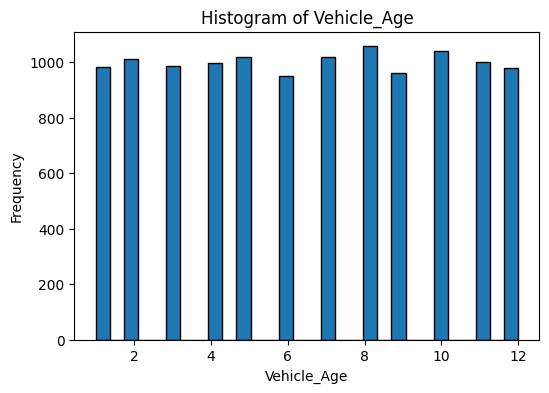

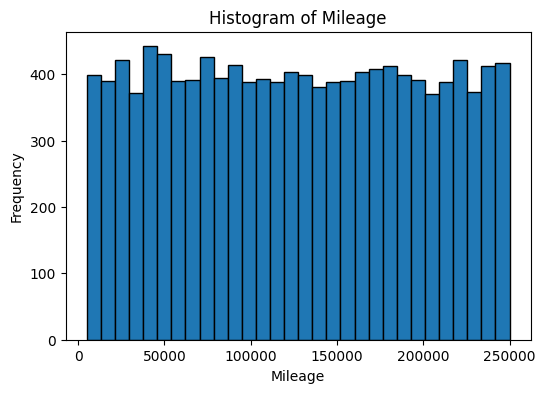

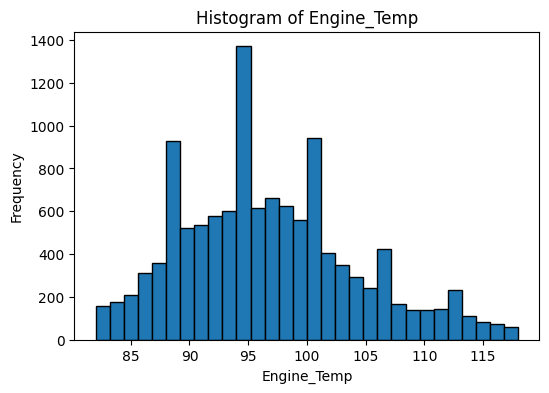

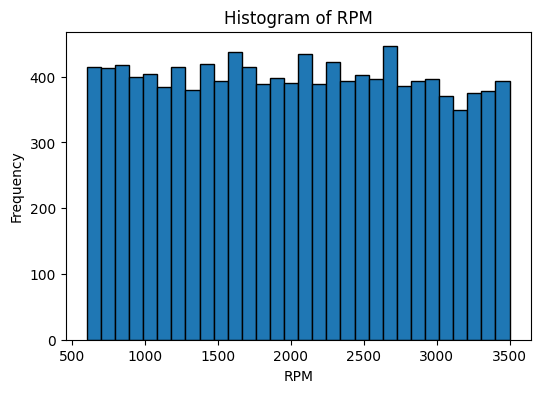

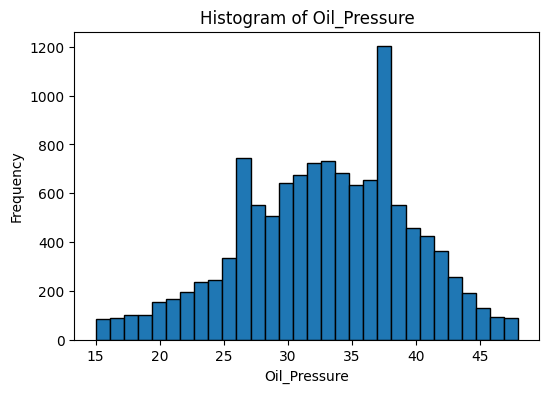

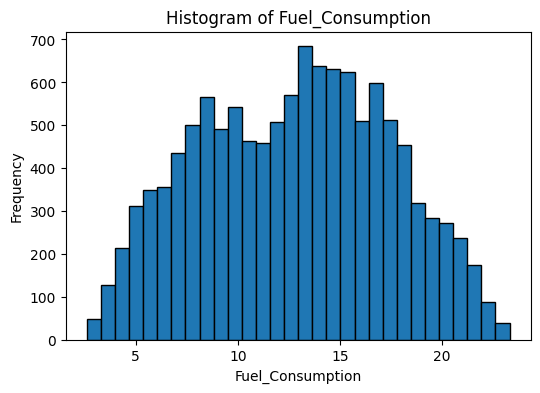

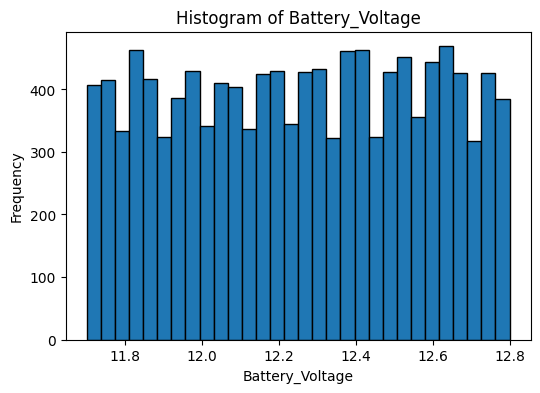

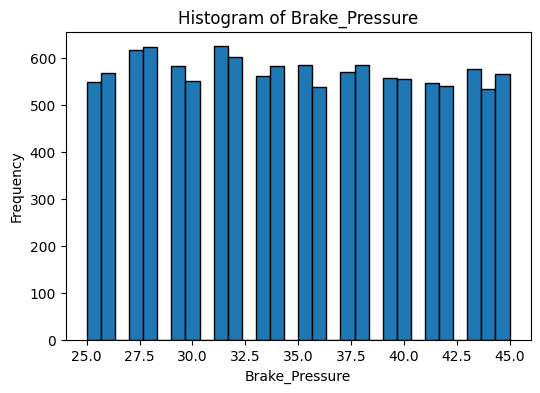

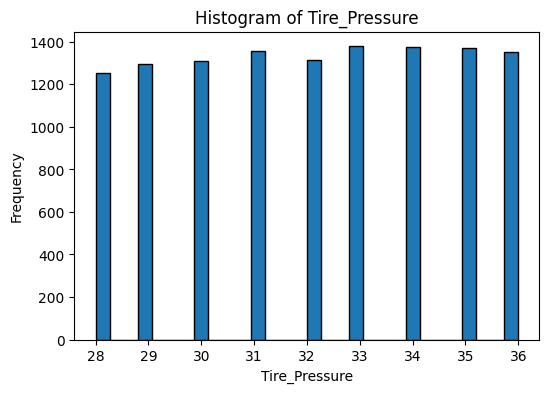

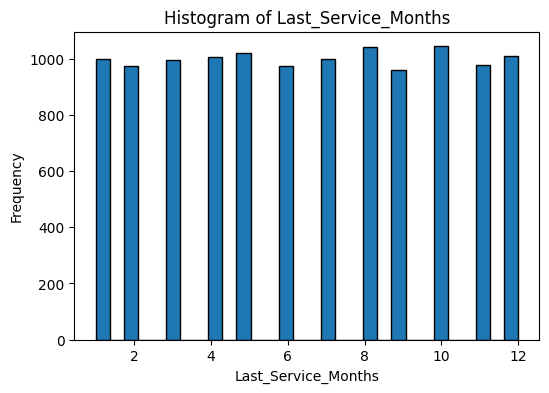

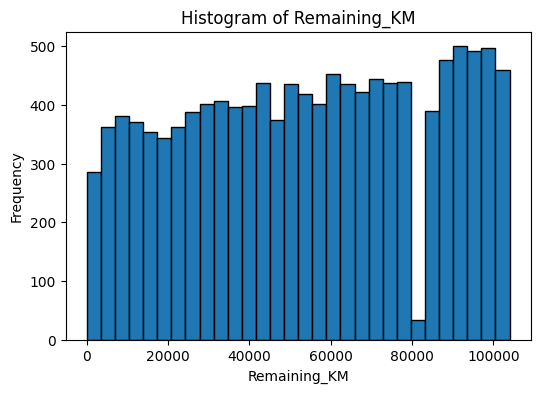

In [8]:
# Histograms

import matplotlib.pyplot as plt

for column in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[column], bins=30, edgecolor="black")
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()


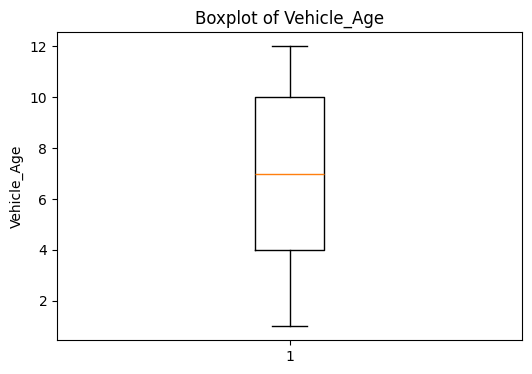

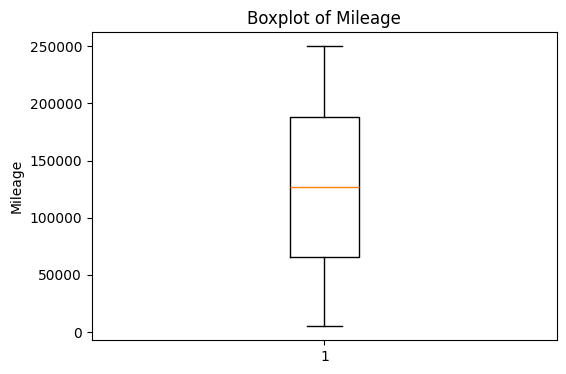

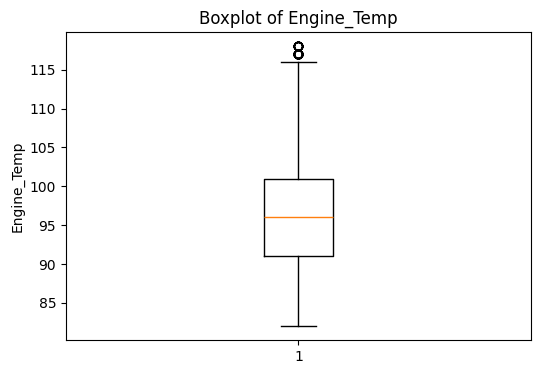

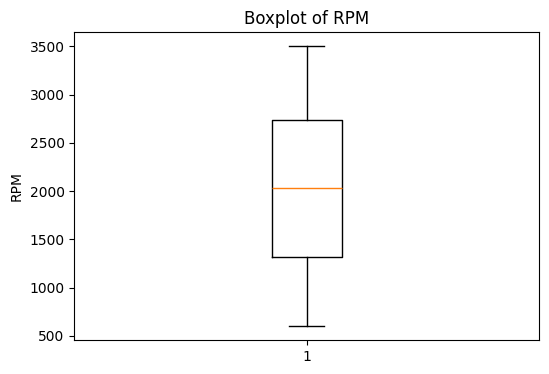

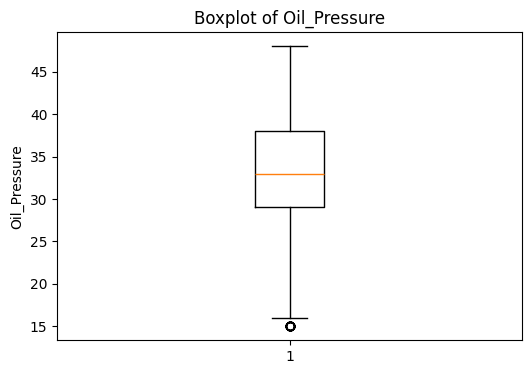

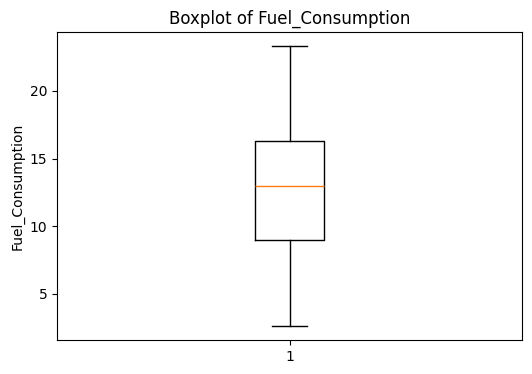

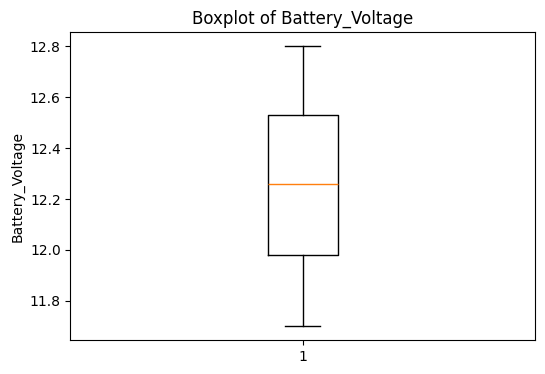

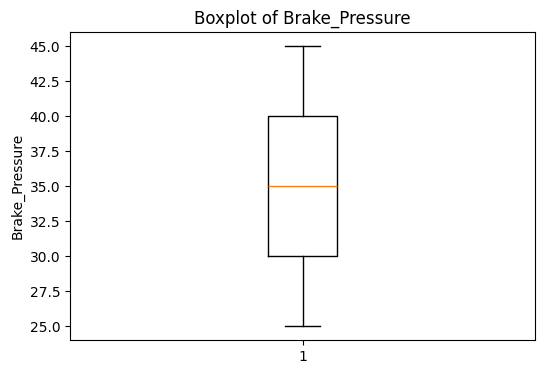

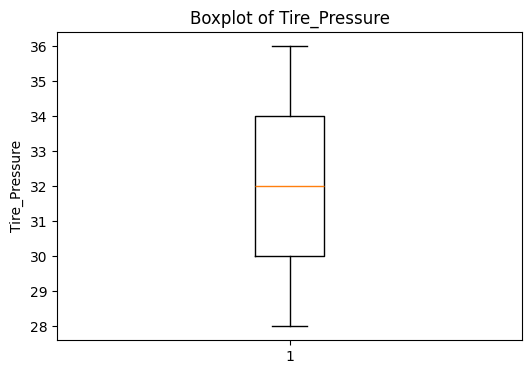

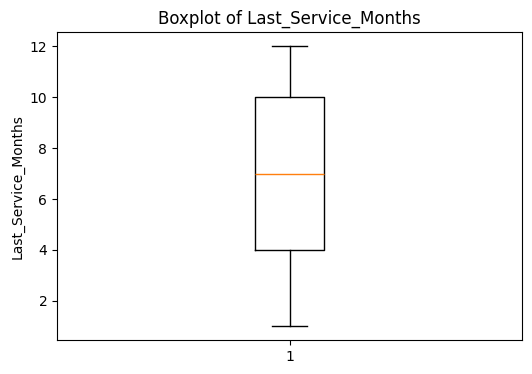

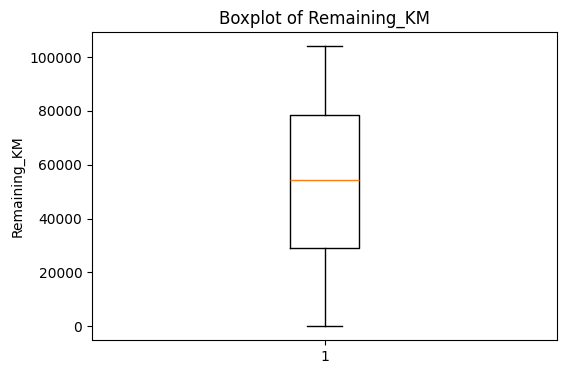

In [9]:
# Boxplots

for column in numerical_features:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[column])
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

In [10]:
# Skewness

for column in numerical_features:
    print(column, ":", round(df[column].skew(), 3))

Vehicle_Age : -0.008
Mileage : 0.013
Engine_Temp : 0.502
RPM : 0.018
Oil_Pressure : -0.263
Fuel_Consumption : -0.02
Battery_Voltage : -0.028
Brake_Pressure : 0.04
Tire_Pressure : -0.032
Last_Service_Months : -0.006
Remaining_KM : -0.043


In [11]:
# Kurtosis

for column in numerical_features:
    print(column, ":", round(df[column].kurt(), 3))

Vehicle_Age : -1.215
Mileage : -1.208
Engine_Temp : -0.167
RPM : -1.179
Oil_Pressure : -0.348
Fuel_Consumption : -0.869
Battery_Voltage : -1.2
Brake_Pressure : -1.202
Tire_Pressure : -1.219
Last_Service_Months : -1.213
Remaining_KM : -1.171


### Histograms
Most numerical features show approximately uniform or symmetric distributions. Engine_Temp is the main exception, showing a moderate right-skewed distribution and several noticeable peaks.

---

### Boxplots
Most numerical features do not show significant outliers. A small number of outliers appear in Engine_Temp and Oil_Pressure, which should be examined further in the outlier analysis.

---

### Skewness
Most features have skewness values close to zero, indicating relatively symmetric distributions. Engine_Temp has the highest skewness (0.502), indicating moderate positive skewness, while Oil_Pressure shows slight negative skewness (-0.263).

---

### Kurtosis
Most variables have negative kurtosis values, indicating flatter distributions with lighter tails than a normal distribution. Engine_Temp has the kurtosis value closest to zero (-0.167).

---

### Conclusion
Overall, most numerical features are relatively symmetric and do not show extreme distributional behavior. Engine_Temp and Oil_Pressure stand out and should receive additional attention in the outlier exploration.

## 2.3 Outlier Exploration

The numerical features will be examined for heavy tails, extreme values, possible noise, measurement artifacts, and data-entry problems.

In [12]:
# Heavy tails analysis using kurtosis

for column in numerical_features:
    print(column, ":", round(df[column].kurt(), 3))

Vehicle_Age : -1.215
Mileage : -1.208
Engine_Temp : -0.167
RPM : -1.179
Oil_Pressure : -0.348
Fuel_Consumption : -0.869
Battery_Voltage : -1.2
Brake_Pressure : -1.202
Tire_Pressure : -1.219
Last_Service_Months : -1.213
Remaining_KM : -1.171


In [13]:
# Extreme values

for column in numerical_features:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(column, ":", len(outliers))

Vehicle_Age : 0
Mileage : 0
Engine_Temp : 60
RPM : 0
Oil_Pressure : 27
Fuel_Consumption : 0
Battery_Voltage : 0
Brake_Pressure : 0
Tire_Pressure : 0
Last_Service_Months : 0
Remaining_KM : 0


In [14]:
# Possible noise

for column in numerical_features:
    data = df[column]

    # IQR
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((data < Q1 - 1.5 * IQR) |
                    (data > Q3 + 1.5 * IQR)).sum()

    # Z-Score
    z_scores = ((data - data.mean()) / data.std()).abs()
    z_outliers = (z_scores > 3).sum()

    # MAD
    median = data.median()
    MAD = (data - median).abs().median()

    if MAD != 0:
        mad_outliers = ((data - median).abs() > 3 * MAD).sum()
    else:
        mad_outliers = 0

    print(column,
          "| IQR:", iqr_outliers,
          "| Z-Score:", z_outliers,
          "| MAD:", mad_outliers)

Vehicle_Age | IQR: 0 | Z-Score: 0 | MAD: 0
Mileage | IQR: 0 | Z-Score: 0 | MAD: 0
Engine_Temp | IQR: 60 | Z-Score: 0 | MAD: 558
RPM | IQR: 0 | Z-Score: 0 | MAD: 0
Oil_Pressure | IQR: 27 | Z-Score: 0 | MAD: 171
Fuel_Consumption | IQR: 0 | Z-Score: 0 | MAD: 0
Battery_Voltage | IQR: 0 | Z-Score: 0 | MAD: 0
Brake_Pressure | IQR: 0 | Z-Score: 0 | MAD: 0
Tire_Pressure | IQR: 0 | Z-Score: 0 | MAD: 0
Last_Service_Months | IQR: 0 | Z-Score: 0 | MAD: 0
Remaining_KM | IQR: 0 | Z-Score: 0 | MAD: 0


In [15]:
# Measurement artifacts

for column in numerical_features:
    print("\n", column)
    print(df[column].value_counts().head(5))


 Vehicle_Age
Vehicle_Age
8     1057
10    1039
7     1017
5     1017
2     1010
Name: count, dtype: int64

 Mileage
Mileage
170779    3
163067    3
83410     3
168334    3
238595    3
Name: count, dtype: int64

 Engine_Temp
Engine_Temp
94    697
95    674
97    660
98    624
96    616
Name: count, dtype: int64

 RPM
RPM
1523    14
2482    12
1806    12
956     11
2356    11
Name: count, dtype: int64

 Oil_Pressure
Oil_Pressure
33    731
32    725
34    681
31    673
36    654
Name: count, dtype: int64

 Fuel_Consumption
Fuel_Consumption
13.1    115
14.3    114
13.2    108
15.1     99
15.5     98
Name: count, dtype: int64

 Battery_Voltage
Battery_Voltage
11.80    133
11.82    129
12.40    129
12.22    129
12.37    127
Name: count, dtype: int64

 Brake_Pressure
Brake_Pressure
31    624
28    623
27    617
32    602
35    584
Name: count, dtype: int64

 Tire_Pressure
Tire_Pressure
33    1378
34    1376
35    1371
31    1355
36    1351
Name: count, dtype: int64

 Last_Service_Months
Last

In [16]:
# Data-entry problems

for column in numerical_features:
    zero_values = (df[column] == 0).sum()
    negative_values = (df[column] < 0).sum()

    print(column,
          "| Zeros:", zero_values,
          "| Negative values:", negative_values)

Vehicle_Age | Zeros: 0 | Negative values: 0
Mileage | Zeros: 0 | Negative values: 0
Engine_Temp | Zeros: 0 | Negative values: 0
RPM | Zeros: 0 | Negative values: 0
Oil_Pressure | Zeros: 0 | Negative values: 0
Fuel_Consumption | Zeros: 0 | Negative values: 0
Battery_Voltage | Zeros: 0 | Negative values: 0
Brake_Pressure | Zeros: 0 | Negative values: 0
Tire_Pressure | Zeros: 0 | Negative values: 0
Last_Service_Months | Zeros: 0 | Negative values: 0
Remaining_KM | Zeros: 0 | Negative values: 0


### Heavy Tails
All numerical features have negative kurtosis values, indicating lighter tails than a normal distribution. Therefore, there is no clear evidence of heavy-tailed behavior.

---

### Extreme Values
The IQR method detected 60 outliers in Engine_Temp and 27 outliers in Oil_Pressure. No outliers were detected in the other numerical features.

---

### Possible Noise
The different detection methods produced different results. IQR and MAD identified unusual values mainly in Engine_Temp and Oil_Pressure, while the Z-Score method detected no extreme observations. This suggests that these values are relatively mild outliers rather than highly extreme noise.

---

### Measurement Artifacts
Several variables contain frequently repeated values, especially discrete measurements such as Vehicle_Age, Engine_Temp, Oil_Pressure, Tire_Pressure, and Last_Service_Months. These repetitions may result from measurement precision or rounding rather than actual measurement errors.

---

### Data-Entry Problems
No zero or negative values were found in any numerical feature. Therefore, there is no clear indication of obvious data-entry problems in the numerical data.

---

### Conclusion
Overall, the dataset does not show severe outlier problems or heavy tails. Engine_Temp and Oil_Pressure contain some unusual observations that should be monitored, but there is currently no strong evidence that they represent errors or invalid data.

# 3. Dimensionality Reduction

## 3.1 Principal Component Analysis (PCA)

PCA will be applied to the numerical features. Since the features are measured on different scales, the data will first be standardized.

In [17]:
# Explained variance ratio

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[numerical_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_

for i, variance in enumerate(explained_variance_ratio, start=1):
    print(f"PC{i}: {variance:.4f}")

PC1: 0.2275
PC2: 0.1011
PC3: 0.0941
PC4: 0.0923
PC5: 0.0912
PC6: 0.0902
PC7: 0.0885
PC8: 0.0885
PC9: 0.0509
PC10: 0.0467
PC11: 0.0291


In [18]:
# Cumulative explained variance

import numpy as np

cumulative_variance = np.cumsum(explained_variance_ratio)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"PC1-PC{i}: {variance:.4f}")

PC1-PC1: 0.2275
PC1-PC2: 0.3285
PC1-PC3: 0.4226
PC1-PC4: 0.5149
PC1-PC5: 0.6061
PC1-PC6: 0.6963
PC1-PC7: 0.7848
PC1-PC8: 0.8733
PC1-PC9: 0.9242
PC1-PC10: 0.9709
PC1-PC11: 1.0000


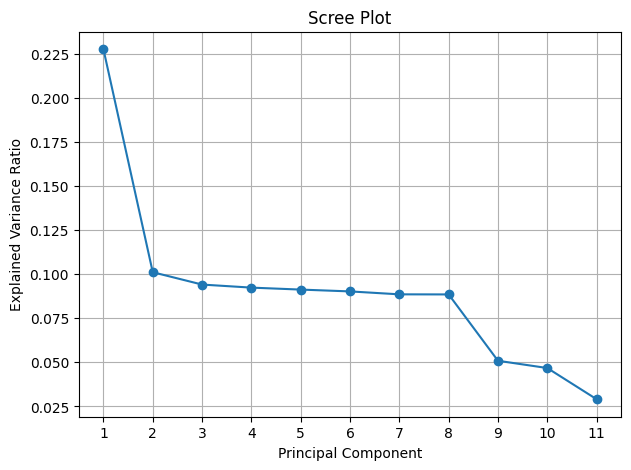

In [19]:
# Scree plot

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o"
)

plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.grid()

plt.show()

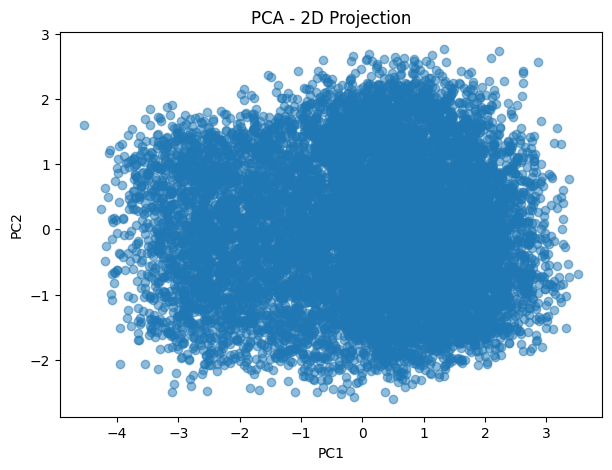

In [20]:
# 2D projection

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    alpha=0.5
)

plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

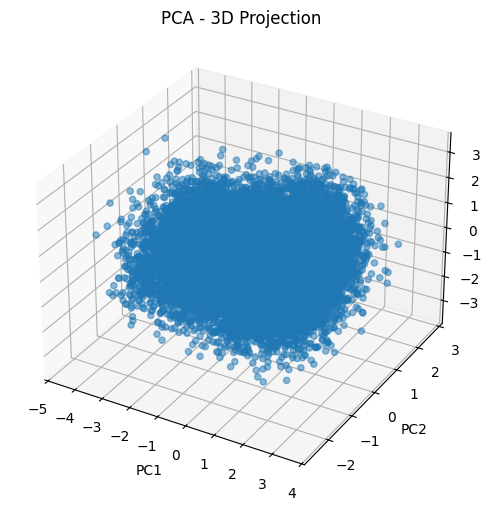

In [21]:
# 3D projection

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    alpha=0.5
)

ax.set_title("PCA - 3D Projection")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()

### PCA Summary

PC1 explains about 22.75% of the total variance. The first two components explain about 32.85%, and the first three explain about 42.26%.

The cumulative explained variance reaches about 87.33% with 8 components, 92.42% with 9 components, and 97.09% with 10 components.

The scree plot shows a large decrease after the first component, followed by a more gradual decrease.

The 2D and 3D projections show that the data points are spread continuously, with no obvious separation into distinct groups.

### How many principal components are needed to adequately represent the data?

Using a 90% explained variance criterion, 9 principal components are needed to represent the data, explaining about 92.42% of the total variance. This means that the dimensionality can be reduced from 11 numerical features to 9 components while keeping most of the information.

---

### How much information is lost when reducing the dimensionality?

Using only 2 principal components keeps about 32.85% of the total variance, meaning that about 67.15% of the information is lost. With 3 components, about 42.26% is preserved and 57.74% is lost. In comparison, using 9 components results in a much smaller information loss of about 7.58%.

---

### Which variables are strongly correlated, and how does this affect the PCA results?

The strongest correlation is between Engine_Temp and Fuel_Consumption (-0.62). Other noticeable correlations include Oil_Pressure and Fuel_Consumption (0.55), Engine_Temp and Remaining_KM (-0.49), and Oil_Pressure and Remaining_KM (0.46).

Since PCA finds directions of maximum variance, correlated variables can contribute to the same principal component. This explains why PC1 captures a relatively large part of the variance compared with the following components.

---

### Interpret the major principal components. Which original variables contribute most to each component?

PC1 is mainly influenced by Engine_Temp, Fuel_Consumption, Oil_Pressure, and Remaining_KM. Therefore, it mainly represents the relationship between engine operating conditions, fuel consumption, and remaining distance.

PC2 is mainly influenced by Last_Service_Months and Remaining_KM, so it can be related to the service history and remaining vehicle usage.

PC3 is mainly influenced by RPM, Mileage, Vehicle_Age, and Battery_Voltage, representing more general vehicle usage and operating characteristics.

The principal components are combinations of the original variables, so these interpretations describe the main patterns represented by each component.

---

### Does the reduced dataset provide a more effective representation of the data than the original dataset?

The PCA results show that the dataset has some redundancy, especially among Engine_Temp, Fuel_Consumption, Oil_Pressure, and Remaining_KM. However, 9 out of 11 components are still required to explain more than 90% of the variance.

Therefore, the dataset does not contain a very high level of redundancy. PCA provides a useful reduced representation, but the dimensionality reduction is relatively limited. The 2D and 3D projections are useful for visualization, but they do not preserve enough variance to fully represent the original dataset.

### Local vs Global Structure

PCA mainly captures the global structure of the dataset by finding directions with the highest variance. It does not directly preserve local relationships between nearby observations. Therefore, it is more useful for understanding the overall structure of the data than small local patterns.

---

### Cluster Separation

The 2D and 3D PCA projections do not show clear separation between groups. The observations form one continuous and dense cloud, so there is no strong evidence of distinct clusters from the PCA visualization alone.

---

### Stability

PC1 explains noticeably more variance than the other components, while several of the following components have relatively similar explained variance ratios. This suggests that the main direction found by PCA is relatively clear, while the exact directions of some later components may be more sensitive to changes in the data.

---

### Computational Cost

The dataset contains 12,000 observations and only 11 numerical features used for PCA. Therefore, the computational cost of PCA is relatively low for this dataset and the method can be applied efficiently.

---

### Interpretability

PCA reduces the data by creating new axes called principal components. These components are combinations of the original variables, which makes them less intuitive to interpret than the original features. However, they are useful for summarizing the main directions of variance in the dataset.

---

### Redundancy

Some redundancy exists because several numerical variables are moderately correlated. However, 9 out of 11 principal components are required to preserve more than 90% of the total variance. Therefore, the overall redundancy in the numerical data is limited, and a strong dimensionality reduction would result in a significant loss of information.

# 4. Clustering Analysis

## 4.1 K-Means Clustering

In [22]:
# Data standardization for clustering

from sklearn.preprocessing import StandardScaler

numerical_features = df.select_dtypes(include="number").columns

X = df[numerical_features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

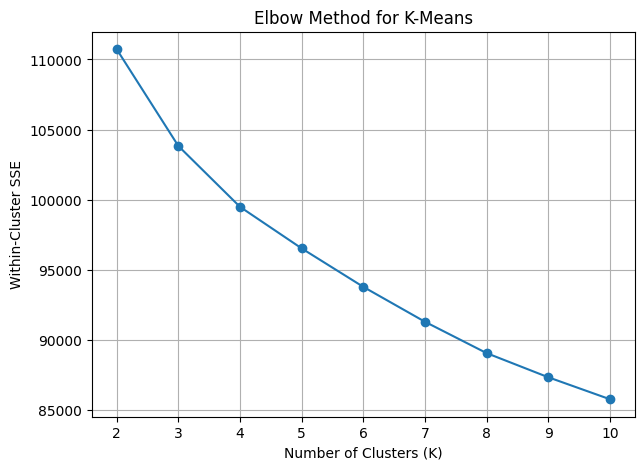

In [23]:
# Choosing K for K-Means - Elbow Method

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(2, 11), inertia_values, marker="o")

plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster SSE")
plt.xticks(range(2, 11))
plt.grid()

plt.show()

In [24]:
# Choosing K for K-Means - Silhouette Score

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.1568
K = 3, Silhouette Score = 0.1031
K = 4, Silhouette Score = 0.0930
K = 5, Silhouette Score = 0.0867
K = 6, Silhouette Score = 0.0718
K = 7, Silhouette Score = 0.0726
K = 8, Silhouette Score = 0.0731
K = 9, Silhouette Score = 0.0724
K = 10, Silhouette Score = 0.0714


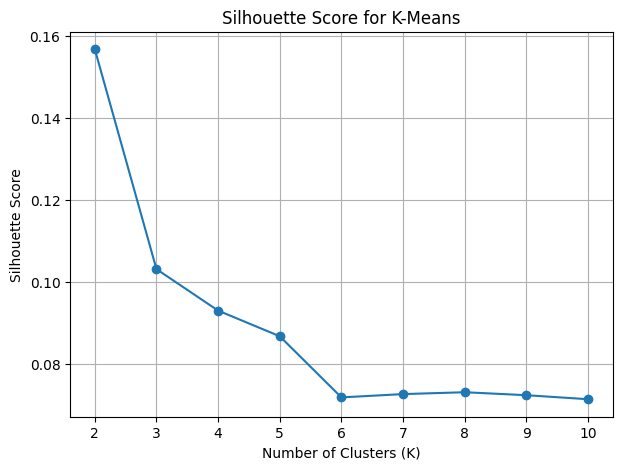

In [25]:
# Silhouette Score Plot

plt.figure(figsize=(7, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.grid()

plt.show()

In [26]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Cluster 0:", (kmeans_labels == 0).sum())
print("Cluster 1:", (kmeans_labels == 1).sum())

Cluster 0: 7854
Cluster 1: 4146


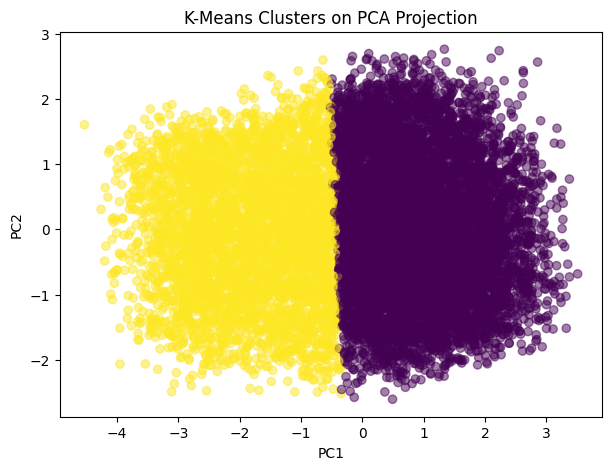

In [27]:
# K-Means clusters on PCA projection

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=kmeans_labels,
    alpha=0.5
)

plt.title("K-Means Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [28]:
# Cluster characteristics

cluster_data = pd.DataFrame(
    X_scaled,
    columns=numerical_features
)

cluster_data["Cluster"] = kmeans_labels

cluster_means = cluster_data.groupby("Cluster").mean()

print(cluster_means.round(3))

         Vehicle_Age  Mileage  Engine_Temp    RPM  Oil_Pressure  \
Cluster                                                           
0              0.009   -0.007       -0.497  0.027         0.457   
1             -0.017    0.014        0.941 -0.052        -0.866   

         Fuel_Consumption  Battery_Voltage  Brake_Pressure  Tire_Pressure  \
Cluster                                                                     
0                   0.528           -0.007           0.002          0.006   
1                  -0.999            0.013          -0.005         -0.011   

         Last_Service_Months  Remaining_KM  
Cluster                                     
0                     -0.060         0.444  
1                      0.113        -0.841  


In [29]:
# Average variance in each cluster vs global variance

global_variance = np.var(X_scaled, axis=0, ddof=1).mean()

print("Global average variance:", round(global_variance, 3))

for cluster in np.unique(kmeans_labels):
    cluster_points = X_scaled[kmeans_labels == cluster]

    cluster_variance = np.var(
        cluster_points,
        axis=0,
        ddof=1
    ).mean()

    print(
        f"Cluster {cluster} average variance:",
        round(cluster_variance, 3)
    )

Global average variance: 1.0
Cluster 0 average variance: 0.84
Cluster 1 average variance: 0.837


### K-Means Analysis

K-Means was applied with K=2 because it gave the highest Silhouette Score (0.1568). Cluster 0 contains 7,854 observations and Cluster 1 contains 4,146 observations.

---

### Cluster Interpretation

Cluster 0 has lower Engine_Temp and higher Oil_Pressure, Fuel_Consumption, and Remaining_KM.

Cluster 1 shows the opposite pattern, with higher Engine_Temp and lower Oil_Pressure, Fuel_Consumption, and Remaining_KM.

The other variables have less influence on the separation between the clusters.

---

### Variance Evaluation

The global average variance is 1.0. The average variance is 0.840 in Cluster 0 and 0.837 in Cluster 1.

This means that the points inside each cluster are slightly more similar to each other than the full dataset.

However, the Silhouette Score is low, so the separation between the two clusters is not very strong.

---

### Strengths and Weaknesses

K-Means is simple, fast, and easy to use.

Its main limitation is that the number of clusters must be selected in advance. It also works better when the clusters are compact and clearly separated.

---

### Conclusion

K-Means found two main groups in the data. The main differences between them are related to Engine_Temp, Oil_Pressure, Fuel_Consumption, and Remaining_KM.

However, the low Silhouette Score shows that the two groups are not strongly separated.

## 4.2 DBSCAN Clustering

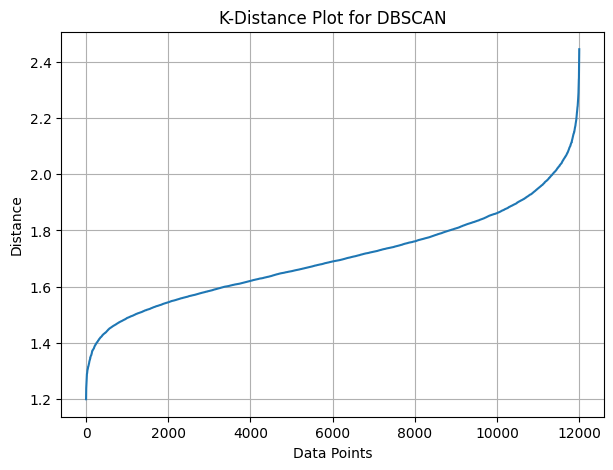

In [30]:
# Choosing eps for DBSCAN

from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances)

plt.title("K-Distance Plot for DBSCAN")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.grid()
plt.show()

In [31]:
# Apply DBSCAN clustering

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=2.0,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    if label == -1:
        print("Noise:", count)
    else:
        print(f"Cluster {label}:", count)

Noise: 54
Cluster 0: 11946


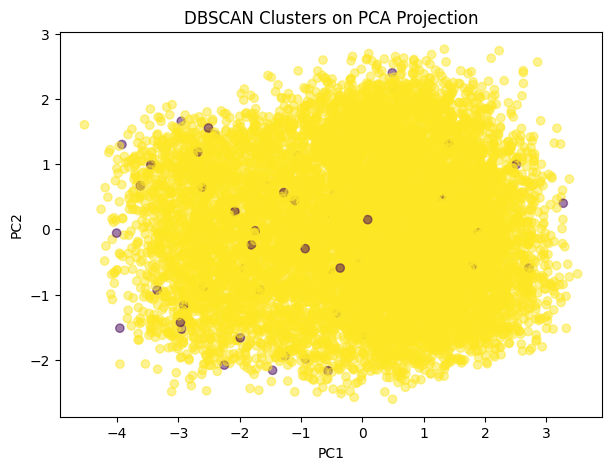

In [32]:
# DBSCAN clusters on PCA projection

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=dbscan_labels,
    alpha=0.5
)

plt.title("DBSCAN Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [33]:
# Testing different eps values for DBSCAN

eps_values = [1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0]

for eps in eps_values:
    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    number_of_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    number_of_noise = (labels == -1).sum()

    print(
        f"eps = {eps} | Clusters: {number_of_clusters} | Noise: {number_of_noise}"
    )

eps = 1.4 | Clusters: 131 | Noise: 10998
eps = 1.5 | Clusters: 221 | Noise: 8423
eps = 1.6 | Clusters: 93 | Noise: 4743
eps = 1.7 | Clusters: 18 | Noise: 1942
eps = 1.8 | Clusters: 3 | Noise: 672
eps = 1.9 | Clusters: 1 | Noise: 192
eps = 2.0 | Clusters: 1 | Noise: 54


In [34]:
# Apply DBSCAN clustering

dbscan = DBSCAN(
    eps=1.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)

for label, count in zip(unique_labels, counts):
    if label == -1:
        print("Noise:", count)
    else:
        print(f"Cluster {label}:", count)

Noise: 672
Cluster 0: 11321
Cluster 1: 4
Cluster 2: 3


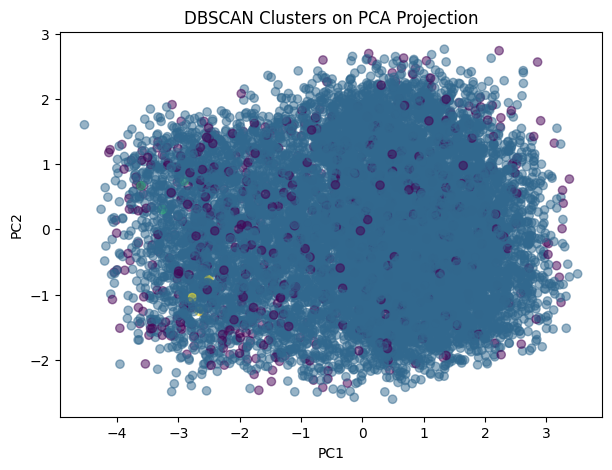

In [35]:
# DBSCAN clusters on PCA projection

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=dbscan_labels,
    alpha=0.5
)

plt.title("DBSCAN Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

### DBSCAN Analysis

DBSCAN was tested with several eps values, and the results changed significantly between the different values.

With eps=1.8 and min_samples=5, most of the data was assigned to one large cluster. Two additional clusters contained only a few observations, and 672 observations were marked as noise.

The PCA projection also shows that the data does not separate clearly into several dense groups.

---

### Strengths and Weaknesses

DBSCAN does not require the number of clusters to be selected in advance and can identify noise points. It can also detect clusters with irregular shapes.

Its main weakness is the sensitivity to eps and min_samples. In this dataset, small changes in eps caused large changes in the number of clusters and noise points.

---

### Conclusion

DBSCAN did not produce a clear clustering structure for this dataset. The main result is one large cluster with a small amount of noise and a few isolated observations.

## 4.3 Hierarchical Clustering

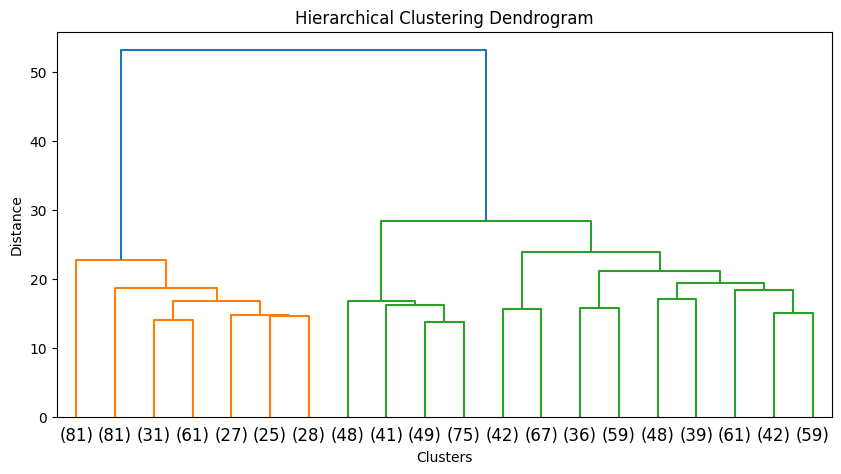

In [36]:
# Hierarchical Clustering - Dendrogram

from scipy.cluster.hierarchy import linkage, dendrogram
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

sample_indices = np.random.choice(
    X_scaled.shape[0],
    size=1000,
    replace=False
)

X_sample = X_scaled[sample_indices]

Z = linkage(X_sample, method="ward")

plt.figure(figsize=(10, 5))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Clusters")
plt.ylabel("Distance")

plt.show()

In [37]:
# Apply Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

hierarchical = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

print("Cluster 0:", (hierarchical_labels == 0).sum())
print("Cluster 1:", (hierarchical_labels == 1).sum())

Cluster 0: 8753
Cluster 1: 3247


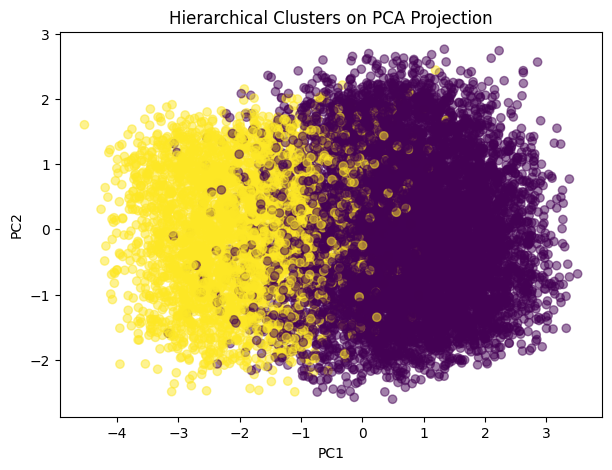

In [38]:
# Hierarchical clusters on PCA projection

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=hierarchical_labels,
    alpha=0.5
)

plt.title("Hierarchical Clusters on PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [39]:
# Hierarchical cluster characteristics

hierarchical_data = pd.DataFrame(
    X_scaled,
    columns=numerical_features
)

hierarchical_data["Cluster"] = hierarchical_labels

hierarchical_means = hierarchical_data.groupby("Cluster").mean()

print(hierarchical_means.round(3))

         Vehicle_Age  Mileage  Engine_Temp    RPM  Oil_Pressure  \
Cluster                                                           
0              0.003    0.023       -0.388  0.009         0.336   
1             -0.008   -0.063        1.046 -0.025        -0.906   

         Fuel_Consumption  Battery_Voltage  Brake_Pressure  Tire_Pressure  \
Cluster                                                                     
0                   0.377           -0.022           0.018         -0.003   
1                  -1.017            0.060          -0.048          0.008   

         Last_Service_Months  Remaining_KM  
Cluster                                     
0                     -0.064         0.371  
1                      0.174        -1.001  


In [40]:
# Average variance in each cluster vs global variance

global_variance = np.var(X_scaled, axis=0, ddof=1).mean()

print("Global average variance:", round(global_variance, 3))

for cluster in np.unique(hierarchical_labels):
    cluster_points = X_scaled[hierarchical_labels == cluster]

    cluster_variance = np.var(
        cluster_points,
        axis=0,
        ddof=1
    ).mean()

    print(
        f"Cluster {cluster} average variance:",
        round(cluster_variance, 3)
    )

Global average variance: 1.0
Cluster 0 average variance: 0.876
Cluster 1 average variance: 0.838


In [41]:
# Silhouette Score for Hierarchical Clustering

from sklearn.metrics import silhouette_score

hierarchical_silhouette = silhouette_score(
    X_scaled,
    hierarchical_labels
)

print(
    "Hierarchical Silhouette Score:",
    round(hierarchical_silhouette, 4)
)

Hierarchical Silhouette Score: 0.1427


### Hierarchical Clustering Analysis

Hierarchical Clustering was applied using Ward linkage and 2 clusters, based on the dendrogram.

Cluster 0 contains 8,753 observations and Cluster 1 contains 3,247 observations.

---

### Cluster Interpretation

Cluster 0 is mainly characterized by lower Engine_Temp and higher Oil_Pressure, Fuel_Consumption, and Remaining_KM.

Cluster 1 shows the opposite pattern, with higher Engine_Temp and lower Oil_Pressure, Fuel_Consumption, and Remaining_KM.

The other variables show smaller differences between the two clusters.

---

### Variance Evaluation

The global average variance is 1.0. The average variance is 0.876 in Cluster 0 and 0.838 in Cluster 1.

This means that the observations inside each cluster are more similar than the full dataset, but the reduction in variance is not very large.

The Silhouette Score is 0.1407, which indicates weak separation between the clusters.

---

### Strengths and Weaknesses

Hierarchical Clustering does not require the cluster structure to be fixed at the beginning, and the dendrogram helps visualize how the groups are formed.

However, the result depends on the linkage method and the chosen cut of the dendrogram. It can also be more computationally expensive for large datasets.

---

### Conclusion

Hierarchical Clustering found two main groups with differences mainly in Engine_Temp, Oil_Pressure, Fuel_Consumption, and Remaining_KM.

However, the low Silhouette Score and the overlap in the PCA projection show that the two clusters are not strongly separated.

##  Clustering on the Feature Space

In [42]:
# Clustering on the Feature Space

X_features = X_scaled.T

print("Original shape:", X_scaled.shape)
print("Transposed shape:", X_features.shape)

Original shape: (12000, 11)
Transposed shape: (11, 12000)


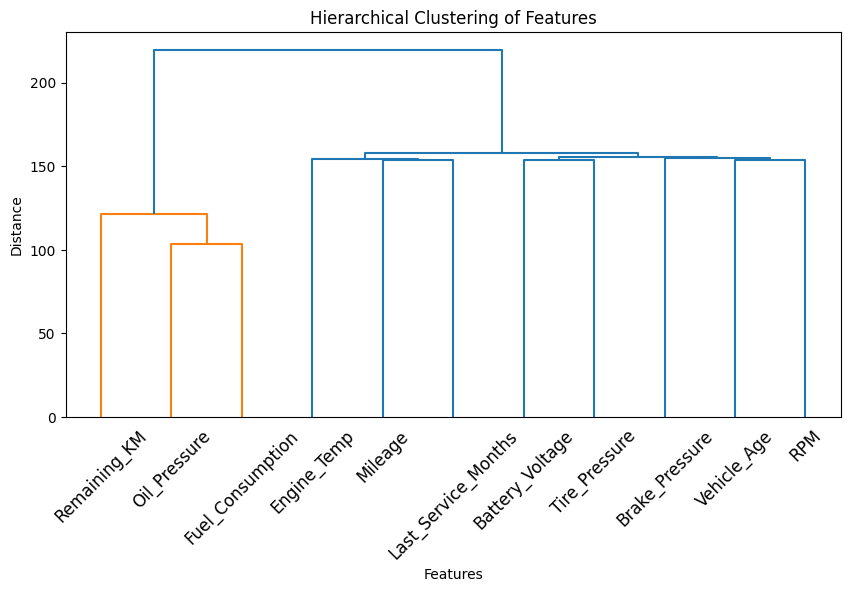

In [43]:
# Hierarchical Clustering on the Feature Space

from scipy.cluster.hierarchy import linkage, dendrogram

feature_linkage = linkage(
    X_features,
    method="ward"
)

plt.figure(figsize=(10, 5))

dendrogram(
    feature_linkage,
    labels=numerical_features,
    leaf_rotation=45
)

plt.title("Hierarchical Clustering of Features")
plt.xlabel("Features")
plt.ylabel("Distance")

plt.show()

In [44]:
# Feature clusters using Hierarchical Clustering

from sklearn.cluster import AgglomerativeClustering

feature_clustering = AgglomerativeClustering(
    n_clusters=2,
    linkage="ward"
)

feature_labels = feature_clustering.fit_predict(X_features)

for feature, label in zip(numerical_features, feature_labels):
    print(feature, ":", label)

Vehicle_Age : 0
Mileage : 0
Engine_Temp : 0
RPM : 0
Oil_Pressure : 1
Fuel_Consumption : 1
Battery_Voltage : 0
Brake_Pressure : 0
Tire_Pressure : 0
Last_Service_Months : 0
Remaining_KM : 1


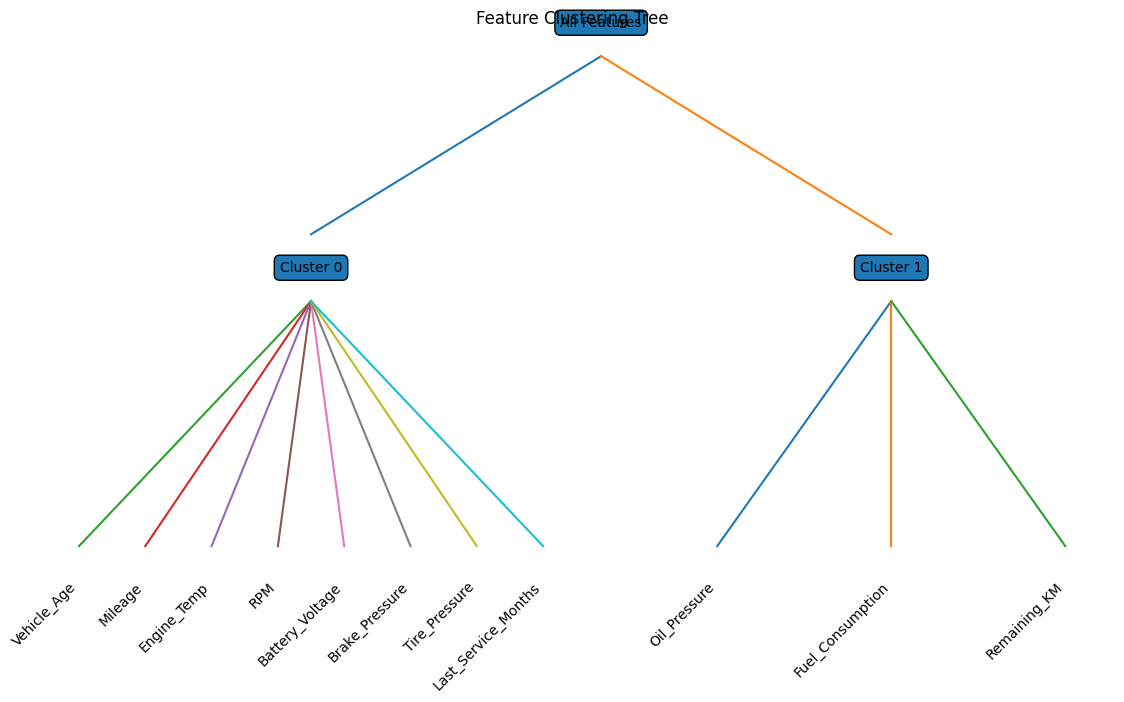

In [45]:
# Feature Clustering Tree Diagram

import matplotlib.pyplot as plt

cluster_0 = [
    feature for feature, label
    in zip(numerical_features, feature_labels)
    if label == 0
]

cluster_1 = [
    feature for feature, label
    in zip(numerical_features, feature_labels)
    if label == 1
]

fig, ax = plt.subplots(figsize=(14, 7))

ax.axis("off")

# Root
root_x = 0.5
root_y = 0.9

ax.text(
    root_x,
    root_y,
    "All Features",
    ha="center",
    va="center",
    bbox=dict(boxstyle="round,pad=0.4")
)

# Cluster positions
cluster_positions = {
    0: (0.25, 0.68),
    1: (0.75, 0.68)
}

for cluster, (x, y) in cluster_positions.items():

    ax.plot(
        [root_x, x],
        [root_y - 0.03, y + 0.03]
    )

    ax.text(
        x,
        y,
        f"Cluster {cluster}",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.4")
    )

# Features in Cluster 0
x_positions_0 = [
    0.05 + i * (0.40 / max(len(cluster_0) - 1, 1))
    for i in range(len(cluster_0))
]

for x, feature in zip(x_positions_0, cluster_0):

    ax.plot(
        [cluster_positions[0][0], x],
        [0.65, 0.43]
    )

    ax.text(
        x,
        0.40,
        feature,
        ha="right",
        va="top",
        rotation=45
    )

# Features in Cluster 1
x_positions_1 = [
    0.60 + i * (0.30 / max(len(cluster_1) - 1, 1))
    for i in range(len(cluster_1))
]

for x, feature in zip(x_positions_1, cluster_1):

    ax.plot(
        [cluster_positions[1][0], x],
        [0.65, 0.43]
    )

    ax.text(
        x,
        0.40,
        feature,
        ha="right",
        va="top",
        rotation=45
    )

plt.title("Feature Clustering Tree")
plt.show()

### What information can be obtained by clustering the features?

Feature clustering shows which variables behave similarly across the dataset. It can help identify relationships between features and groups of variables that may contain similar information.

---

### Did the analysis reveal groups of related or redundant features?

Yes. Oil_Pressure, Fuel_Consumption, and Remaining_KM were grouped together. These variables also showed noticeable relationships in the correlation analysis.

This suggests some redundancy between these features, although the overall redundancy in the dataset is limited.

---

### Were there features that appeared isolated or significantly different from the others?

No feature formed a completely separate cluster. However, most features were separated from the group containing Oil_Pressure, Fuel_Consumption, and Remaining_KM.

Engine_Temp also showed relationships with these variables, but mainly through negative correlation, so it was not placed in the same feature cluster.

---

### Did this analysis provide insights that were not visible when clustering the samples directly?

Yes. Sample clustering showed groups of vehicles with different operating conditions, while feature clustering showed which measurements behave similarly.

This gives a different view of the dataset and helps identify relationships between variables that are not as clear when clustering the observations.

---

### In what types of problems or domains might clustering features be particularly useful?

Feature clustering can be useful in datasets with many measurements, such as sensor data, vehicle monitoring, IoT systems, medical measurements, and financial data.

It can help identify related variables, reduce redundant features, and simplify the dataset.

---

### Did clustering the feature space help uncover hidden structure, dependencies, correlations, or potential feature hierarchies within the dataset?

Yes. The analysis showed a clear group containing Oil_Pressure, Fuel_Consumption, and Remaining_KM, indicating a relationship between these variables.

The hierarchical structure also showed how different features are gradually grouped based on their similarity. This supports the correlation and PCA results and shows that some dependencies exist, but the overall redundancy of the dataset is limited.

### Evaluate

In [46]:
# Silhouette Score

from sklearn.metrics import silhouette_score

kmeans_score = silhouette_score(X_scaled, kmeans_labels)
hierarchical_score = silhouette_score(X_scaled, hierarchical_labels)

# Remove DBSCAN noise points
mask = dbscan_labels != -1

dbscan_score = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print("K-Means:", round(kmeans_score, 4))
print("Hierarchical:", round(hierarchical_score, 4))
print("DBSCAN:", round(dbscan_score, 4))


K-Means: 0.1568
Hierarchical: 0.1427
DBSCAN: 0.0933


In [47]:
# Average variance in each cluster vs global variance

global_variance = np.var(X_scaled, axis=0).mean()

print("Global variance:", round(global_variance, 3))

# K-Means
for cluster in [0, 1]:
    cluster_data = X_scaled[kmeans_labels == cluster]
    variance = np.var(cluster_data, axis=0).mean()
    print("K-Means Cluster", cluster, ":", round(variance, 3))

# Hierarchical
for cluster in [0, 1]:
    cluster_data = X_scaled[hierarchical_labels == cluster]
    variance = np.var(cluster_data, axis=0).mean()
    print("Hierarchical Cluster", cluster, ":", round(variance, 3))

# DBSCAN
for cluster in [0, 1, 2]:
    cluster_data = X_scaled[dbscan_labels == cluster]
    variance = np.var(cluster_data, axis=0).mean()
    print("DBSCAN Cluster", cluster, ":", round(variance, 3))

Global variance: 1.0
K-Means Cluster 0 : 0.84
K-Means Cluster 1 : 0.836
Hierarchical Cluster 0 : 0.876
Hierarchical Cluster 1 : 0.838
DBSCAN Cluster 0 : 0.974
DBSCAN Cluster 1 : 0.118
DBSCAN Cluster 2 : 0.08


### Evaluate

The Silhouette Score was highest for K-Means with 0.1568. Hierarchical Clustering received 0.1407 and DBSCAN received 0.0933.

These values are quite low, so the separation between the clusters is not very strong.

For K-Means, the average variances inside the clusters are 0.840 and 0.836, compared with the global variance of 1.0. For Hierarchical Clustering, the values are 0.876 and 0.838. This means that the observations inside the clusters are slightly more similar than the dataset as a whole.

For DBSCAN, the main cluster has a variance of 0.974, which is very close to the global variance. The other two clusters have much lower variance, but they contain only a few observations, so these values should be interpreted carefully.

The variance inside the clusters helps us understand how compact the clusters are. However, it does not tell us how separated the clusters are from each other.

For this reason, the Silhouette Score is also useful, because it considers both the similarity inside a cluster and the distance from other clusters.

Among the methods tested, K-Means gave the highest Silhouette Score. However, the low score suggests that the dataset does not contain very clear or strongly separated clusters.

### Visualize

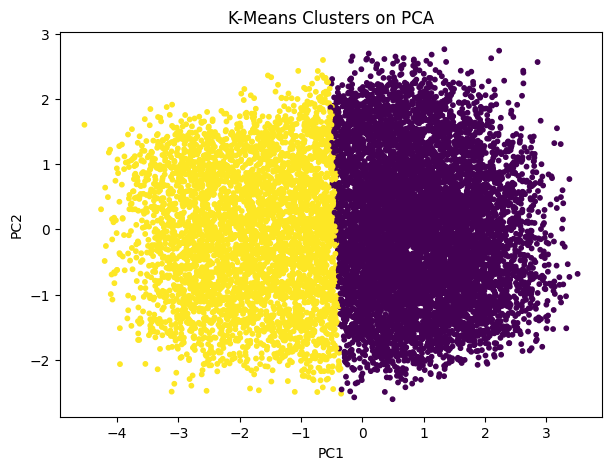

In [48]:
# K-Means clusters on PCA

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA")
plt.show()

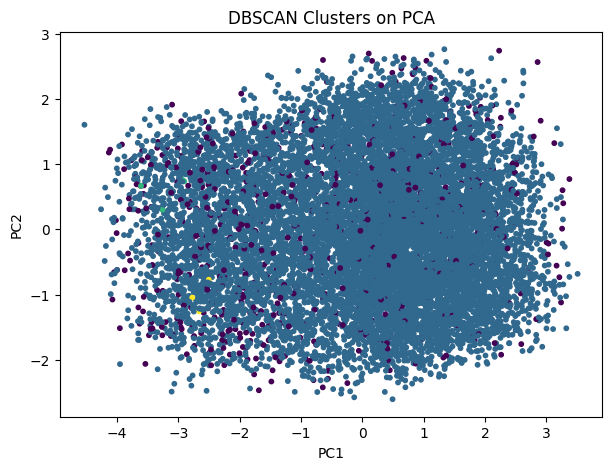

In [49]:
# DBSCAN clusters on PCA

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=dbscan_labels,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters on PCA")
plt.show()

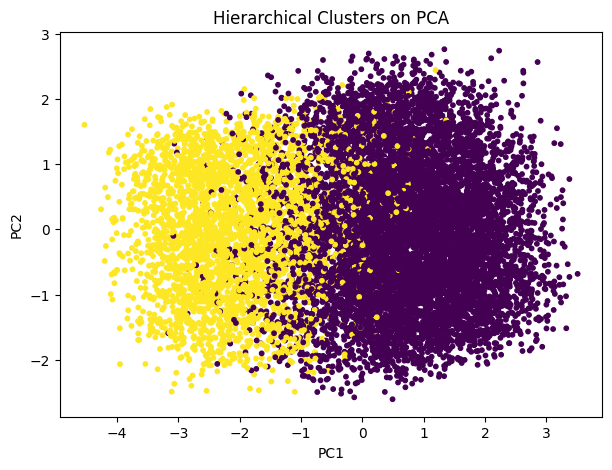

In [50]:
# Hierarchical clusters on PCA

plt.figure(figsize=(7, 5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=hierarchical_labels,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Hierarchical Clusters on PCA")
plt.show()

### PCA Visualization Analysis

The PCA plots show that K-Means and Hierarchical Clustering divide the data mainly along the first principal component.

However, there is still a noticeable overlap between the groups, which agrees with the relatively low Silhouette Scores.

DBSCAN shows a different result. Most observations belong to one large cluster, while a smaller number of points are marked as noise or belong to very small clusters.

Overall, the PCA visualization supports the previous results and suggests that the dataset does not contain clearly separated clusters.

### Discussion

#### Why different algorithms produce different clusters

Each algorithm defines clusters in a different way.

K-Means groups observations according to the nearest centroid, DBSCAN looks for dense areas, and Hierarchical Clustering joins observations step by step according to their similarity.

Because of this, K-Means and Hierarchical Clustering found two main groups, while DBSCAN mainly found one large cluster and some noise points.

---

#### Sensitivity to hyperparameters

The methods showed different sensitivity to their parameters.

For K-Means, the main parameter is K. In our analysis, K=2 gave the highest Silhouette Score.

DBSCAN was more sensitive. Small changes in eps caused large changes in the number of clusters and noise points.

For Hierarchical Clustering, the result depends on the linkage method and the point where the dendrogram is cut.

---

#### Cluster geometry

The PCA plots showed that the observations form a mostly continuous cloud with overlap between the groups.

K-Means usually works better with compact and separated clusters. This may explain why its Silhouette Score was relatively low.

DBSCAN can also detect irregular cluster shapes, but in this dataset it did not find several clear dense regions.

---

#### Density-based vs centroid-based approaches

K-Means is centroid-based, so every observation is assigned to one of the clusters.

DBSCAN is density-based, so it can identify dense regions and also mark some observations as noise.

In our results, K-Means divided the data into two groups, while DBSCAN placed most observations in one large cluster.

---

#### Situations where clustering may fail

Clustering may give weak results when the data does not contain clear natural groups.

K-Means may have problems with overlapping or irregular clusters. DBSCAN may have problems when the density changes across the dataset or when eps and min_samples are not chosen well.

Hierarchical Clustering can be sensitive to the linkage method and may also be more expensive for large datasets.

In our dataset, the low Silhouette Scores suggest that the natural separation between clusters is not very strong.

---

### Summary and Conclusions

In this section, three clustering methods were tested: K-Means, DBSCAN, and Hierarchical Clustering.

K-Means and Hierarchical Clustering both found two main groups, but the separation between them was not very strong. DBSCAN gave a different result and mainly found one large cluster with some noise points.

The Silhouette Scores were relatively low for all methods, which suggests that the dataset does not contain very clear natural clusters.

The main variables that influenced the separation were Engine_Temp, Oil_Pressure, Fuel_Consumption, and Remaining_KM.

Clustering the feature space also showed that Oil_Pressure, Fuel_Consumption, and Remaining_KM behave in a similar way and form a clear feature group.

Overall, the clustering analysis revealed some structure in the data, but the groups are not strongly separated. This means that clustering is useful here for finding patterns and relationships, but the results should be interpreted carefully.

# 5. Multi-Dimensional Anomaly Detection

## 5.1 Z-Score Method

In [51]:
# Apply a classical Z-score method

from scipy.stats import zscore

z_scores = abs(zscore(X))

z_scores = pd.DataFrame(
    z_scores,
    columns=numerical_features
)

zscore_anomaly = (z_scores > 3).any(axis=1)

print("Number of anomalies:", zscore_anomaly.sum())
print("Percentage of anomalies:",
      round(zscore_anomaly.mean() * 100, 2), "%")

Number of anomalies: 0
Percentage of anomalies: 0.0 %


In [52]:
# Anomalies by feature

feature_anomalies = (z_scores > 3).sum()

print(feature_anomalies)

Vehicle_Age            0
Mileage                0
Engine_Temp            0
RPM                    0
Oil_Pressure           0
Fuel_Consumption       0
Battery_Voltage        0
Brake_Pressure         0
Tire_Pressure          0
Last_Service_Months    0
Remaining_KM           0
dtype: int64


In [53]:
# Detected anomalies

df[zscore_anomaly].head(10)

,Vehicle_Type,Vehicle_Age,Mileage,Engine_Temp,RPM,Oil_Pressure,Fuel_Consumption,Battery_Voltage,Brake_Pressure,Tire_Pressure,Tire_Condition,Vibration_Level,Last_Service_Months,Accident_History,KM_Range_Before_Defect,Remaining_KM


### Assumption of Gaussianity

The Z-Score method is a statistical method that measures how far a value is from the mean in terms of standard deviations.

It works better when the data is approximately normally distributed. From the EDA, most features were not strongly skewed, but many of them were not clearly Gaussian.

Using the classical threshold of |Z| > 3, no anomalies were detected. This may mean that the threshold is too strict for the distributions in this dataset.

---

### Why this approach may fail in high dimensions

Z-Score examines each feature separately.

In high-dimensional data, an observation can be unusual because of the combination of several features, even if none of the individual values is very far from its mean.

In our dataset, no single feature passed the |Z| > 3 threshold. However, this does not necessarily mean that there are no unusual observations when several variables are considered together.

This is one reason why other methods, such as Isolation Forest and LOF, may detect anomalies that Z-Score does not detect.

---

### Feature-wise vs global anomaly detection

The Z-Score method used here is mainly feature-wise. Each numerical feature is checked separately, and an observation is marked as anomalous if at least one feature has |Z| > 3.

In our results, no feature crossed this threshold, so no observations were marked as anomalies.

Global anomaly detection methods look at the full observation using several features together. Because of this, they may find unusual patterns that are not visible when checking each feature separately.

Therefore, the result of zero anomalies with Z-Score should be interpreted carefully and compared with the other anomaly detection methods.

## 5.2 Isolation Forest

In [54]:
# Apply Isolation Forest

from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_labels = iso_forest.fit_predict(X)

iso_anomaly = iso_labels == -1

print("Number of anomalies:", iso_anomaly.sum())
print("Percentage of anomalies:",
      round(iso_anomaly.mean() * 100, 2), "%")

Number of anomalies: 240
Percentage of anomalies: 2.0 %


In [55]:
# Anomaly scores

iso_scores = iso_forest.decision_function(X)

print("Lowest anomaly scores:")
print(np.sort(iso_scores)[:10])

Lowest anomaly scores:
[-0.04767351 -0.04232037 -0.03972343 -0.03617854 -0.03594536 -0.03480351
 -0.03452455 -0.03426856 -0.03423537 -0.03390068]


In [56]:
# Contamination parameter

for contamination in [0.01, 0.02, 0.05]:

    model = IsolationForest(
        contamination=contamination,
        random_state=42
    )

    labels = model.fit_predict(X)
    anomalies = (labels == -1).sum()

    print("Contamination:", contamination,
          "- Anomalies:", anomalies)

Contamination: 0.01 - Anomalies: 120
Contamination: 0.02 - Anomalies: 240
Contamination: 0.05 - Anomalies: 600


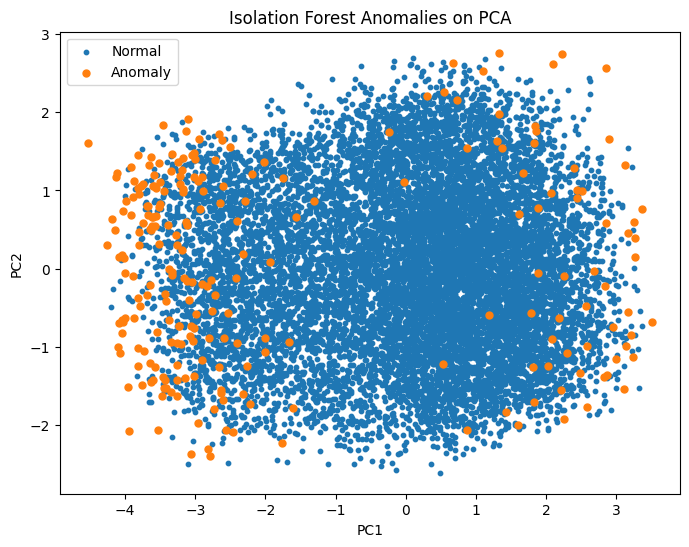

In [57]:
# Visualize detected anomalies

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[~iso_anomaly, 0],
    X_pca[~iso_anomaly, 1],
    s=10,
    label="Normal"
)

plt.scatter(
    X_pca[iso_anomaly, 0],
    X_pca[iso_anomaly, 1],
    s=25,
    label="Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Isolation Forest Anomalies on PCA")
plt.legend()
plt.show()

### Explain the isolation mechanism used by the algorithm

Isolation Forest tries to separate observations by repeatedly splitting the data.

At each step, the algorithm randomly chooses a feature and a split value. Observations that are unusual are usually easier to separate from the rest of the data and therefore need fewer splits.

The algorithm builds many isolation trees and combines their results to decide which observations are more likely to be anomalies.

---

### Explain the role of random partitioning in identifying anomalous observations

Random partitioning is an important part of Isolation Forest.

For each tree, a feature and a split point are selected randomly. This process is repeated until observations become isolated.

Normal observations usually belong to dense areas and need more partitions before they are isolated. Anomalous observations are usually separated after fewer partitions.

Using many random trees makes the result less dependent on one specific split.

---

### Discuss the contamination parameter and its effect on the results

The contamination parameter represents the expected proportion of anomalies in the dataset.

We tested contamination values of 0.01, 0.02 and 0.05. They produced 120, 240 and 600 anomalies respectively.

Using the automatic setting at first produced a very large number of anomalies, so we selected contamination = 0.02 for the final analysis.

With this value, 240 observations were detected as anomalies, which is 2% of the dataset.

This shows that the contamination parameter has a direct effect on how many observations are classified as anomalous, so it should be selected carefully.

---

### Discuss the advantages and limitations of the method, particularly in high-dimensional datasets

One advantage of Isolation Forest is that it can work efficiently with high-dimensional datasets. It is also scalable and does not depend directly on distance between observations.

Another advantage is that feature scaling is not required in the same way as distance-based methods.

A limitation is that the result can depend on parameter choices such as contamination. Also, random partitions may not always represent complex structures in the data correctly.

In our dataset, the method was able to identify anomalies even though the Z-Score method detected none.

---

### Explain how the anomaly score is calculated and interpret what a high or low score represents

The anomaly score is related to the number of splits needed to isolate an observation across the isolation trees.

Observations that are isolated after only a few splits are considered more unusual, while observations that require more splits are considered more normal.

In the `decision_function` used here, lower scores represent more anomalous observations. Negative scores are classified as anomalies, while higher scores represent more normal observations.

---

### Visualize detected anomalies

The PCA visualization shows that many of the detected anomalies appear around the outer parts of the data distribution.

However, some anomalies also appear inside the main PCA cloud. This can happen because Isolation Forest uses all numerical features, while the PCA graph only shows PC1 and PC2.

Therefore, two observations that look close in the 2D PCA plot may still be different when all original features are considered.


## 5.3 Local Outlier Factor (LOF)

In [58]:
# Apply LOF

from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_labels = lof.fit_predict(X_scaled)

lof_anomaly = lof_labels == -1

print("Number of anomalies:", lof_anomaly.sum())
print("Percentage of anomalies:",
      round(lof_anomaly.mean() * 100, 2), "%")

Number of anomalies: 240
Percentage of anomalies: 2.0 %


In [59]:
# LOF scores

lof_scores = lof.negative_outlier_factor_

print("Lowest LOF scores:")
print(np.sort(lof_scores)[:10])

Lowest LOF scores:
[-1.26260325 -1.25333424 -1.24221387 -1.24157365 -1.24007753 -1.23243242
 -1.2310954  -1.22658173 -1.22330228 -1.222655  ]


In [60]:
# Sensitivity to parameter k

lof_results = {}

for k in [10, 20, 50]:

    model = LocalOutlierFactor(
        n_neighbors=k,
        contamination=0.02
    )

    labels = model.fit_predict(X_scaled)

    lof_results[k] = labels == -1

    print("k =", k,
          "- Anomalies:", lof_results[k].sum())

k = 10 - Anomalies: 240
k = 20 - Anomalies: 240
k = 50 - Anomalies: 240


In [61]:
# Compare anomalies for different k values

print("Overlap k=10 and k=20:",
      np.sum(lof_results[10] & lof_results[20]))

print("Overlap k=20 and k=50:",
      np.sum(lof_results[20] & lof_results[50]))

print("Overlap k=10 and k=50:",
      np.sum(lof_results[10] & lof_results[50]))

Overlap k=10 and k=20: 184
Overlap k=20 and k=50: 185
Overlap k=10 and k=50: 153


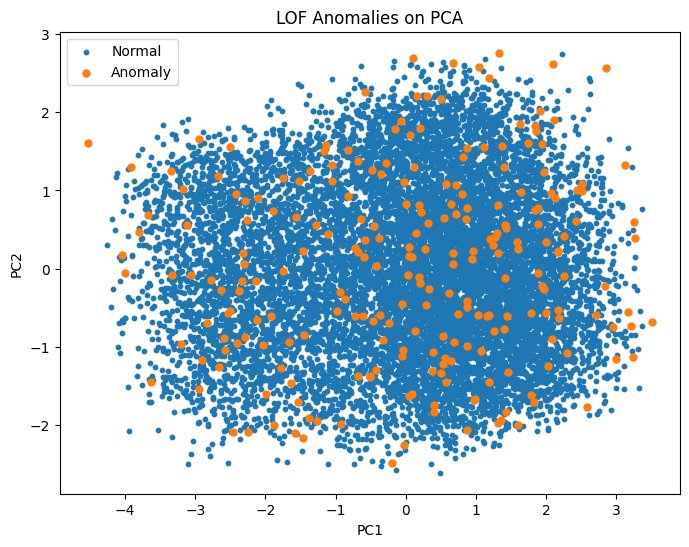

In [62]:
# Visualize anomalies

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[~lof_anomaly, 0],
    X_pca[~lof_anomaly, 1],
    s=10,
    label="Normal"
)

plt.scatter(
    X_pca[lof_anomaly, 0],
    X_pca[lof_anomaly, 1],
    s=25,
    label="Anomaly"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("LOF Anomalies on PCA")
plt.legend()
plt.show()

### Local density estimation

LOF detects anomalies by comparing the local density of each observation with the density of its neighbors.

If an observation is located in an area with much lower density than the points around it, LOF gives it a higher level of abnormality.

In our analysis, 240 observations were detected as anomalies using k=20 and contamination=0.02.

---

### Neighborhood effects

The result of LOF depends on the neighborhood around each observation.

A point may be considered normal in one dense region but unusual compared with the observations in its own local area.

This is important because LOF does not only look for observations that are far from the entire dataset. It looks for observations that are different from their nearby neighbors.

---

### Sensitivity to parameter k

The parameter k controls how many neighbors are used to estimate the local density.

We tested k=10, k=20 and k=50. Because contamination was fixed at 0.02, all three values detected 240 anomalies.

However, the overlap between the detected anomalies was not complete. This means that changing k changes which observations are classified as anomalous.

A smaller k focuses on a more local neighborhood, while a larger k considers a wider area of the dataset.

---

### Difference between global and local anomalies

A global anomaly is an observation that is unusual compared with the dataset as a whole.

A local anomaly may not look very unusual globally, but it can be different from the observations in its local neighborhood.

LOF is mainly designed to detect local anomalies. This is different from methods such as Z-Score, which compare values with the overall mean and standard deviation.

This difference may explain why LOF detected anomalies even though the Z-Score method detected none.

---

### Visualize anomalies

The PCA plot shows that the LOF anomalies are spread across different parts of the data.

Some of them appear near the edges of the distribution, while others appear inside the main data cloud.

This makes sense for LOF because it uses local density. A point can be locally unusual even if it does not appear extreme in the two-dimensional PCA plot.

Also, the PCA graph shows only two principal components, while LOF was applied using all numerical features.

# 6. Comparison Section

In [63]:
# Compare anomaly detection methods

comparison = pd.DataFrame({
    "Z-Score": zscore_anomaly,
    "Isolation Forest": iso_anomaly,
    "LOF": lof_anomaly
})

print("Z-Score anomalies:", comparison["Z-Score"].sum())
print("Isolation Forest anomalies:", comparison["Isolation Forest"].sum())
print("LOF anomalies:", comparison["LOF"].sum())

Z-Score anomalies: 0
Isolation Forest anomalies: 240
LOF anomalies: 240


In [64]:
# Agreement between methods

iso_lof_overlap = (
    comparison["Isolation Forest"] &
    comparison["LOF"]
).sum()

zscore_iso_overlap = (
    comparison["Z-Score"] &
    comparison["Isolation Forest"]
).sum()

zscore_lof_overlap = (
    comparison["Z-Score"] &
    comparison["LOF"]
).sum()

print("Isolation Forest and LOF:", iso_lof_overlap)
print("Z-Score and Isolation Forest:", zscore_iso_overlap)
print("Z-Score and LOF:", zscore_lof_overlap)

Isolation Forest and LOF: 61
Z-Score and Isolation Forest: 0
Z-Score and LOF: 0


In [65]:
# Method-specific anomalies

only_iso = (
    comparison["Isolation Forest"] &
    ~comparison["LOF"]
).sum()

only_lof = (
    comparison["LOF"] &
    ~comparison["Isolation Forest"]
).sum()

print("Only Isolation Forest:", only_iso)
print("Only LOF:", only_lof)

Only Isolation Forest: 179
Only LOF: 179


### Which anomalies are identified by multiple methods? Discuss the level of agreement between the methods.

Isolation Forest and LOF both detected 240 anomalies, but only 61 observations were detected by both methods.

Z-Score did not detect any anomalies, so there was no overlap between Z-Score and the other methods.

The agreement between Isolation Forest and LOF is therefore limited. This suggests that the two methods are looking at different types of unusual behavior in the data.

---

### Which anomalies are method-specific? Explain why different methods may identify different observations as anomalous.

Isolation Forest detected 179 anomalies that were not detected by LOF, and LOF also detected 179 anomalies that were not detected by Isolation Forest.

This difference is reasonable because the methods use different ideas. Isolation Forest tries to isolate unusual observations using random partitions, while LOF compares the local density of each observation with the density of its neighbors.

Because of this, an observation may look unusual globally and be detected by Isolation Forest, but still look normal compared with its local neighborhood. The opposite can also happen with LOF.

Z-Score detected no anomalies because none of the individual features passed the |Z| > 3 threshold.

### Compare the sensitivity of the methods to feature scaling.

In [66]:
# Z-Score sensitivity to feature scaling

z_scaled = abs(zscore(X_scaled))
z_scaled_anomaly = (z_scaled > 3).any(axis=1)

z_overlap = (zscore_anomaly & z_scaled_anomaly).sum()

print("Original anomalies:", zscore_anomaly.sum())
print("Scaled anomalies:", z_scaled_anomaly.sum())
print("Overlap:", z_overlap)

Original anomalies: 0
Scaled anomalies: 0
Overlap: 0


In [67]:
# Isolation Forest sensitivity to feature scaling

iso_scaled = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_scaled_labels = iso_scaled.fit_predict(X_scaled)
iso_scaled_anomaly = iso_scaled_labels == -1

iso_scaling_overlap = (
    iso_anomaly & iso_scaled_anomaly
).sum()

print("Original anomalies:", iso_anomaly.sum())
print("Scaled anomalies:", iso_scaled_anomaly.sum())
print("Overlap:", iso_scaling_overlap)

Original anomalies: 240
Scaled anomalies: 240
Overlap: 240


In [68]:
# LOF sensitivity to feature scaling

lof_unscaled = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_unscaled_labels = lof_unscaled.fit_predict(X)
lof_unscaled_anomaly = lof_unscaled_labels == -1

lof_scaling_overlap = (
    lof_anomaly & lof_unscaled_anomaly
).sum()

print("Scaled anomalies:", lof_anomaly.sum())
print("Unscaled anomalies:", lof_unscaled_anomaly.sum())
print("Overlap:", lof_scaling_overlap)

Scaled anomalies: 240
Unscaled anomalies: 240
Overlap: 8


### Compare the sensitivity of the methods to feature scaling

The three methods behaved differently when feature scaling was tested.

For Z-Score, the result did not change. No anomalies were detected before or after scaling. This is reasonable because Z-Score already measures each value relative to the mean and standard deviation of its own feature.

Isolation Forest also showed no change. It detected 240 anomalies before scaling and 240 after scaling, and all 240 observations were the same. This shows that Isolation Forest was not sensitive to feature scaling in our dataset.

LOF showed a very different result. It detected 240 anomalies in both cases because the contamination parameter was fixed at 0.02, but only 8 observations were common between the scaled and unscaled results.

This shows that LOF was highly sensitive to feature scaling. Since LOF uses distances and local neighborhoods, features with larger numerical ranges can dominate the distance calculation when the data is not scaled.

Overall, scaling had almost no effect on Z-Score and Isolation Forest, but it had a strong effect on LOF.

### Compare the sensitivity of the methods to the dimensionality of the data

In [69]:
# Z-Score sensitivity to dimensionality

for n in [2, 5, 9]:

    data_pca = X_pca[:, :n]

    z = abs(zscore(data_pca))
    anomalies = (z > 3).any(axis=1)

    print("Dimensions:", n,
          "- Anomalies:", anomalies.sum())

Dimensions: 2 - Anomalies: 0
Dimensions: 5 - Anomalies: 12
Dimensions: 9 - Anomalies: 31


In [70]:
# Isolation Forest sensitivity to dimensionality

for n in [2, 5, 9]:

    data_pca = X_pca[:, :n]

    model = IsolationForest(
        contamination=0.02,
        random_state=42
    )

    labels = model.fit_predict(data_pca)
    anomalies = labels == -1

    overlap = (iso_anomaly & anomalies).sum()

    print("Dimensions:", n,
          "- Anomalies:", anomalies.sum(),
          "- Overlap:", overlap)

Dimensions: 2 - Anomalies: 240 - Overlap: 78
Dimensions: 5 - Anomalies: 240 - Overlap: 92
Dimensions: 9 - Anomalies: 240 - Overlap: 87


In [71]:
# LOF sensitivity to dimensionality

for n in [2, 5, 9]:

    data_pca = X_pca[:, :n]

    model = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.02
    )

    labels = model.fit_predict(data_pca)
    anomalies = labels == -1

    overlap = (lof_anomaly & anomalies).sum()

    print("Dimensions:", n,
          "- Anomalies:", anomalies.sum(),
          "- Overlap:", overlap)

Dimensions: 2 - Anomalies: 240 - Overlap: 18
Dimensions: 5 - Anomalies: 240 - Overlap: 46
Dimensions: 9 - Anomalies: 240 - Overlap: 108


### Compare the sensitivity of the methods to the dimensionality of the data

The three methods were affected differently when the number of dimensions was changed.

For Z-Score, using 2 principal components detected no anomalies, while 5 components detected 12 and 9 components detected 31. This shows that reducing the dimensionality can hide unusual behavior that becomes visible when more information is included.

Isolation Forest always detected 240 anomalies because the contamination parameter was fixed at 0.02. However, the overlap with the anomalies detected in the full feature space changed between the different dimensions. This shows that the selected dimensions can affect which observations are considered anomalous.

LOF showed an even stronger change. With 2 principal components, only 18 anomalies overlapped with the original LOF result. With 5 components the overlap increased to 46, and with 9 components it increased to 108.

This makes sense because LOF depends on distances and local neighborhoods. When dimensions are removed, the neighborhood structure can change significantly.

Overall, dimensionality reduction changed the anomaly detection results for all methods. The effect was especially noticeable for LOF, which is more dependent on the geometry and local distances in the data.

### Compare the computational runtime and scalability of the methods.

In [72]:
# Z-Score runtime

import time

start = time.time()

z = abs(zscore(X))
z_anomalies = (z > 3).any(axis=1)

end = time.time()

print("Z-Score runtime:",
      round(end - start, 4), "seconds")

Z-Score runtime: 0.0068 seconds


In [73]:
# Isolation Forest runtime

start = time.time()

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

labels = model.fit_predict(X)

end = time.time()

print("Isolation Forest runtime:",
      round(end - start, 4), "seconds")

Isolation Forest runtime: 0.4287 seconds


In [74]:
# LOF runtime

start = time.time()

model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

labels = model.fit_predict(X_scaled)

end = time.time()

print("LOF runtime:",
      round(end - start, 4), "seconds")


LOF runtime: 3.4998 seconds


### Compare the computational runtime and scalability of the methods

The three methods showed clear differences in runtime.

Z-Score was the fastest method, with a runtime of about 0.016 seconds. This is expected because it only calculates the mean and standard deviation for each feature and then checks the distance from the mean.

Isolation Forest took about 1.60 seconds. It was slower than Z-Score because it builds many isolation trees, but the runtime was still relatively low for 12,000 observations.

LOF was the slowest method, with a runtime of about 5.12 seconds. This is reasonable because LOF needs to find nearby neighbors and calculate local density for each observation.

In terms of scalability, Z-Score is the simplest and fastest method. Isolation Forest is also considered efficient and scalable for larger and high-dimensional datasets. LOF may become more computationally expensive as the number of observations and dimensions increases.

Overall, Z-Score was the fastest in our dataset, Isolation Forest had a moderate runtime, and LOF required the most computation.

### Discuss the robustness of each method to noise in the data

In [75]:
# Robustness to noise

np.random.seed(42)

noise = np.random.normal(
    0,
    0.05,
    X_scaled.shape
)

X_noisy = X_scaled + noise


In [76]:
# Z-Score robustness to noise

z_original = abs(zscore(X_scaled))
z_original_anomaly = (z_original > 3).any(axis=1)

z_noisy = abs(zscore(X_noisy))
z_noisy_anomaly = (z_noisy > 3).any(axis=1)

print("Original anomalies:", z_original_anomaly.sum())
print("With noise:", z_noisy_anomaly.sum())

Original anomalies: 0
With noise: 0


In [77]:
# Isolation Forest robustness to noise

iso_original = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_original_labels = iso_original.fit_predict(X_scaled)
iso_original_anomaly = iso_original_labels == -1

iso_noisy = IsolationForest(
    contamination=0.02,
    random_state=42
)

iso_noisy_labels = iso_noisy.fit_predict(X_noisy)
iso_noisy_anomaly = iso_noisy_labels == -1

iso_noise_overlap = (
    iso_original_anomaly & iso_noisy_anomaly
).sum()

print("Original anomalies:", iso_original_anomaly.sum())
print("With noise:", iso_noisy_anomaly.sum())
print("Overlap:", iso_noise_overlap)

Original anomalies: 240
With noise: 240
Overlap: 156


In [78]:
# LOF robustness to noise

lof_original = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_original_labels = lof_original.fit_predict(X_scaled)
lof_original_anomaly = lof_original_labels == -1

lof_noisy = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

lof_noisy_labels = lof_noisy.fit_predict(X_noisy)
lof_noisy_anomaly = lof_noisy_labels == -1

lof_noise_overlap = (
    lof_original_anomaly & lof_noisy_anomaly
).sum()

print("Original anomalies:", lof_original_anomaly.sum())
print("With noise:", lof_noisy_anomaly.sum())
print("Overlap:", lof_noise_overlap)

Original anomalies: 240
With noise: 240
Overlap: 208


### Discuss the robustness of each method to noise in the data

The methods reacted differently when a small amount of noise was added to the data.

Z-Score did not detect any anomalies before or after adding noise. In this test, the small noise was not enough to create values above the |Z| > 3 threshold.

Isolation Forest detected 240 anomalies in both cases, but only 156 of them were the same observations. This means that the noise changed part of the anomaly detection result.

LOF also detected 240 anomalies before and after adding noise, and 208 observations were common between the two results. In our experiment, LOF was more stable than Isolation Forest under this small amount of noise.

LOF is based on local density and neighboring observations, so changes in the data can affect the local neighborhood. Isolation Forest uses random partitions, so small changes can also affect how easily some observations are isolated.

Overall, all methods kept a similar number of anomalies, but the actual observations detected by Isolation Forest and LOF changed. This shows why robustness should be checked using the detected observations and not only the total number of anomalies.

### Compare the interpretability of the methods and their results

Z-Score is the easiest method to interpret. It directly shows how far a value is from the mean in units of standard deviation. In our dataset, no observation passed the |Z| > 3 threshold, so the result was simple to understand.

Isolation Forest is less direct, but the main idea is still intuitive. Observations that can be isolated with fewer random splits are considered more unusual. Its result can be understood using the anomaly score, but it is harder to explain which exact feature caused an observation to be detected.

LOF is also less simple than Z-Score because it depends on local density and neighboring observations. A point can be considered anomalous only because it is different from its local neighborhood, even if it does not look extreme globally.

Overall, Z-Score is the most interpretable method. Isolation Forest and LOF can detect more complex anomalies, but their decisions are more difficult to explain directly.

### Discuss false positives and false negatives in the context of your dataset

A false positive happens when a normal vehicle observation is classified as anomalous.

In our dataset, this could mean that a vehicle with unusual but still acceptable values of temperature, pressure, mileage, or fuel consumption is incorrectly flagged as a possible problem.

Too many false positives could lead to unnecessary inspections or maintenance.

A false negative happens when a truly abnormal vehicle condition is classified as normal.

This could be more serious because a real mechanical problem may be missed. For example, an unusual combination of Engine_Temp, Oil_Pressure, or other measurements could indicate a possible fault but may not be detected by the method.

The Z-Score method may have a higher risk of false negatives in our case because it detected no anomalies. Isolation Forest and LOF detected more unusual observations, but some of these may also be false positives.

Since the dataset does not contain labels showing which observations are truly abnormal, we cannot know the exact number of false positives and false negatives. The results should therefore be interpreted as possible anomalies that may require further investigation.

# 7. Critical Analysis and Reflection

### Explain why anomaly detection is fundamentally a difficult and ill-defined problem

Anomaly detection is difficult because there is usually no clear definition of what is abnormal.

In unsupervised data there are no labels, and different methods may detect different observations.

This happened in our dataset. Z-Score detected no anomalies, while Isolation Forest and LOF detected 240 each, with only partial overlap.

This shows that the result depends on the method, its assumptions, and its parameters, so anomaly detection should always be interpreted in the context of the data.

### Discuss the curse of dimensionality and its effect on anomaly detection methods

As the number of dimensions increases, the data becomes more spread out and it becomes harder to measure similarity between observations.

This can make anomaly detection more difficult, especially for methods that depend on distances or neighborhoods.

In our results, LOF was affected strongly when we changed the number of dimensions, which fits this idea.

Isolation Forest was also affected, but less directly because it is based on random partitions rather than nearest-neighbor distances.

### Explain why distance-based measures may become less meaningful as the dimensionality of the data increases

When the number of dimensions increases, distances between observations can become more similar.

This makes it harder to clearly separate close and far points.

Methods such as LOF can be affected because they depend on nearest neighbors and local distances.

This is one reason why high-dimensional data can make anomaly detection less reliable.

### Discuss the difference between noise and a genuine anomaly. Provide an example from your dataset of an observation that may be detected as anomalous but is nevertheless a legitimate instance.

Noise is usually caused by measurement errors or random variation, while a genuine anomaly represents a real but unusual observation.

For example, a vehicle with an unusually high Engine_Temp may be detected as anomalous, but the measurement can still be valid if the vehicle was operating under unusual conditions.

Therefore, an unusual value should not automatically be treated as an error. The real-world context is also important.

### Discuss the risks of assuming that the data follow a Gaussian distribution. What types of anomalies might be incorrectly identified or missed because of this assumption?

Assuming a Gaussian distribution can be risky when the real data has a different shape.

Values in the tails may be marked as anomalies even if they are valid, while unusual observations in non-Gaussian regions may be missed.

In our dataset, several features were not clearly Gaussian, so this assumption may partly explain why Z-Score detected no anomalies.

### Explain why visualizations obtained after dimensionality reduction (e.g., PCA or any other dimension reduction technique) may provide a misleading picture of anomalies or clusters in the original high-dimensional space

PCA keeps only part of the original information.

When the data is reduced to 2D or 3D, some differences between observations may disappear.

Because of this, two points can look close in the PCA plot but still be very different in the original feature space.

This happened in our anomaly plots, where some points detected as anomalies still appeared inside the main PCA cloud.

### Ethical Considerations

#### Discuss the real-world consequences of false alarms. When might too many false alarms make an anomaly detection system ineffective?

A false alarm happens when normal behavior is classified as abnormal.

Too many false alarms can waste time and resources. In our vehicle dataset, this could lead to unnecessary inspections or maintenance.

If the system gives too many false alarms, users may stop trusting it and may ignore real warnings.

---

#### Discuss the use of anomaly detection in surveillance. What are the potential benefits and risks?

Anomaly detection can help identify unusual or suspicious behavior in surveillance systems.

The benefit is that possible threats can be detected earlier.

However, normal behavior may also be classified as suspicious. This can create privacy problems and may lead to people being investigated without a real reason.

---

#### Discuss anomaly detection in medical applications. What could be the consequences of incorrectly classifying a patient as anomalous or normal?

In medical applications, anomaly detection can help identify unusual test results or patient conditions.

A false positive may cause unnecessary tests, stress, or treatment.

A false negative can be more serious because a real medical problem may be missed.

For this reason, anomaly detection should support medical decisions and not replace professional judgment.

---

#### Discuss anomaly detection in cybersecurity. Compare the potential consequences of missing a genuine attack with those of incorrectly flagging legitimate activity as malicious.

In cybersecurity, anomaly detection can help identify attacks or unusual user activity.

Missing a real attack may allow damage, data theft, or unauthorized access.

On the other hand, incorrectly flagging normal activity can block legitimate users and create unnecessary work for security teams.

A good system should therefore try to balance between detecting real threats and reducing false alarms.

---

#### Discuss the ethical considerations associated with anomaly detection. In particular, consider privacy, bias, fairness, and the consequences of labeling individuals or behaviors as "abnormal."

Anomaly detection can create ethical problems when it is used on people or personal data.

Privacy can be affected if large amounts of personal information are collected and analyzed.

Bias in the data may also cause some groups to be flagged more often than others, which can create unfair results.

Also, being labeled as "abnormal" does not necessarily mean that a person or behavior is wrong. The result should always be interpreted carefully and in the correct context.

# 8. Final Visualization Dashboard (Bonus)

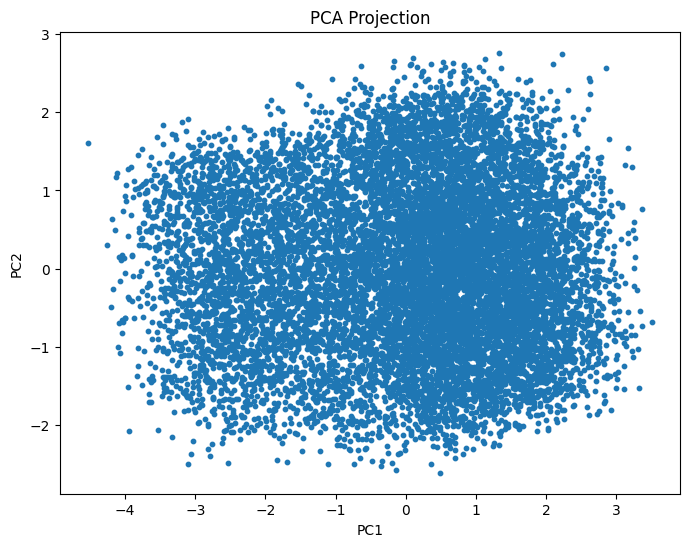

In [79]:
# PCA visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

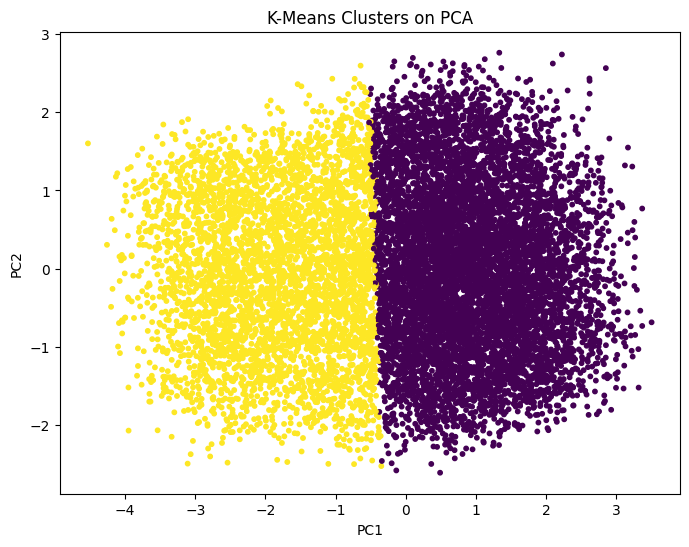

In [80]:
# Cluster visualization

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    s=10
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters on PCA")
plt.show()

In [81]:
# Interactive anomaly exploration

import plotly.express as px

anomaly_plot = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Isolation_Forest": np.where(
        iso_anomaly,
        "Anomaly",
        "Normal"
    )
})

fig = px.scatter(
    anomaly_plot,
    x="PC1",
    y="PC2",
    color="Isolation_Forest",
    title="Interactive Isolation Forest Anomaly Exploration"
)

fig.show()

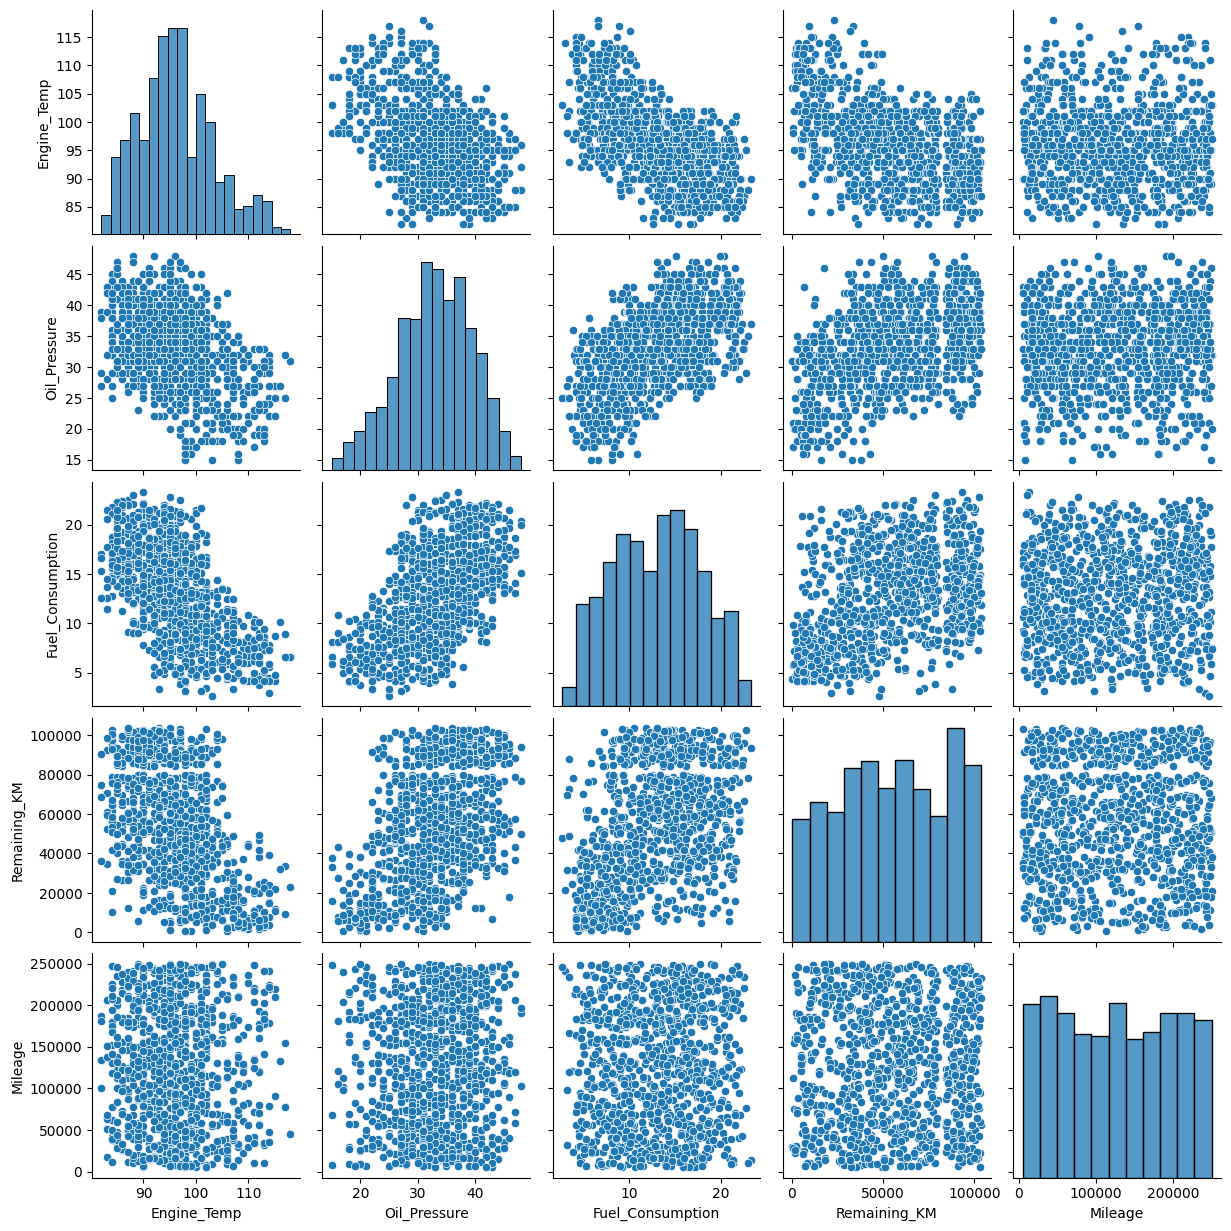

In [82]:
# Pairplots

import seaborn as sns

pairplot_features = [
    "Engine_Temp",
    "Oil_Pressure",
    "Fuel_Consumption",
    "Remaining_KM",
    "Mileage"
]

pairplot_data = df[pairplot_features].sample(
    1000,
    random_state=42
)

sns.pairplot(pairplot_data)
plt.show()

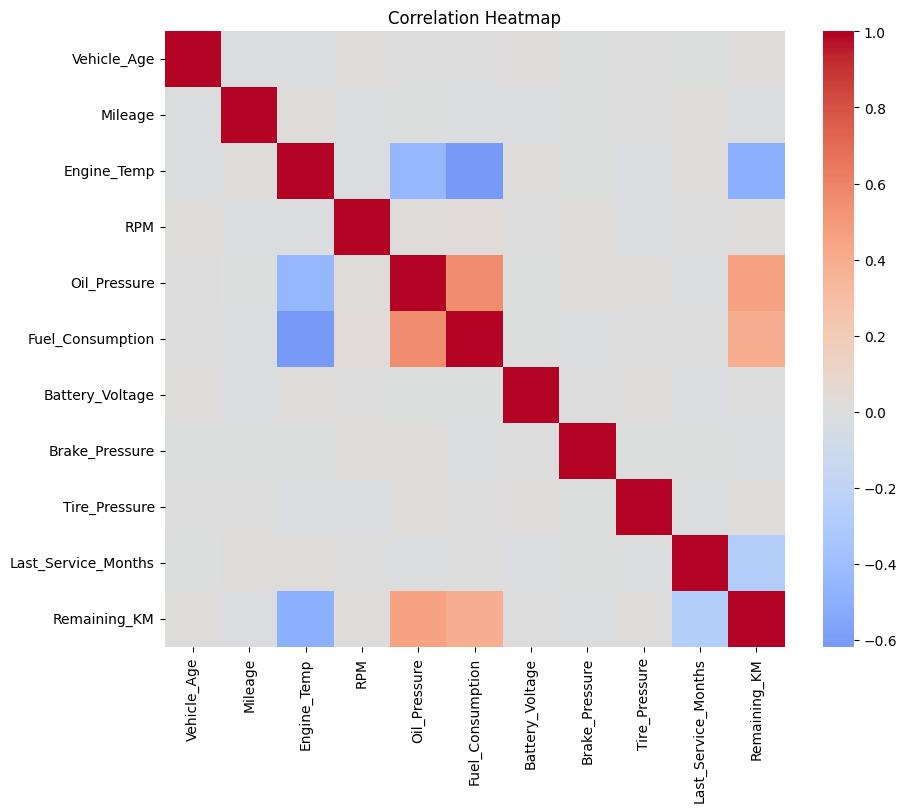

In [83]:
# Heatmap

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numerical_features].corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

### Dashboard Summary

The dashboard gives a visual summary of the main results of the analysis.

The PCA plot shows the general structure of the data, while the cluster visualization shows the weak separation found by K-Means.

The interactive anomaly plot allows the detected anomalies to be explored more easily.

The pairplot helps compare relationships between some of the main numerical variables, and the heatmap summarizes the correlations between all numerical features.

Together, these visualizations give a clearer overview of the patterns, clusters, and anomalies found in the dataset.

# Overall Summary and Real-World Conclusions

The purpose of this project was to understand the structure of the vehicle dataset using EDA, PCA, clustering, and anomaly detection.

The EDA showed that the dataset is complete, with no missing values and only a small number of extreme values. Most numerical features did not show strong skewness or heavy tails.

PCA showed that the dataset cannot be reduced to only two or three dimensions without losing a large amount of information. About 9 principal components were needed to keep more than 90% of the variance. This suggests that most features still contain useful information and that the dataset has only limited redundancy.

---

## Clustering Conclusions

K-Means, DBSCAN, and Hierarchical Clustering gave different results.

K-Means and Hierarchical Clustering found two main groups, but the Silhouette Scores were low. DBSCAN mainly found one large group with some noise.

This suggests that the vehicles do not naturally form very clear and separated groups.

Some variables, especially Engine_Temp, Oil_Pressure, Fuel_Consumption, and Remaining_KM, had a stronger influence on the clustering results.

Feature clustering also showed that Oil_Pressure, Fuel_Consumption, and Remaining_KM behave in a relatively similar way.

An important conclusion is that we should not force the data into clear groups if the natural separation is weak.

---

## Anomaly Detection Conclusions

The anomaly detection methods also produced different results.

Z-Score detected no anomalies, while Isolation Forest and LOF detected 240 anomalies each. However, only 61 observations were detected by both methods.

This shows that there is no single definition of an anomaly.

Z-Score looks mainly for extreme individual values, Isolation Forest looks for observations that can be isolated easily, and LOF looks for observations that are unusual compared with their local neighborhood.

The results also showed that LOF was very sensitive to feature scaling and dimensionality.

Therefore, an anomaly should not automatically be treated as a real fault. It should first be investigated using the vehicle context and other measurements.

---

## Connection to Real Life

In a real vehicle monitoring or predictive maintenance system, these methods could help identify vehicles that may need further inspection.

However, it would not be safe to make maintenance decisions based only on one feature or one algorithm.

For example, a vehicle with high mileage may still be completely normal. A high engine temperature may also be acceptable under some operating conditions.

A better system would combine several sensor readings, anomaly detection methods, historical information, and professional knowledge before deciding that a vehicle has a real problem.

---

## Challenging Simple Assumptions

Some results also challenge simple assumptions about vehicle data.

For example, Vehicle_Age and Mileage had almost no correlation in this dataset. This means that an older vehicle was not necessarily a vehicle with much higher mileage.

Another example is that an extreme or unusual measurement does not automatically mean that the vehicle is faulty. It may represent normal variation, a different operating condition, or measurement noise.

The clustering results also showed that not every dataset naturally contains clear groups such as "good vehicles" and "bad vehicles."

These results remind us that simple assumptions should be checked with data instead of being accepted automatically.

---

## Final Conclusion

The main lesson from this project is that data analysis is not only about applying algorithms.

Different methods can give different answers because they use different assumptions and definitions.

In this dataset, PCA showed limited redundancy, clustering showed weak natural separation, and anomaly detection showed significant disagreement between methods.

For a real-world application, the most useful approach would be to combine several methods and interpret their results together with domain knowledge.

The algorithms can help find suspicious patterns, but the final decision should still depend on the real meaning of the data.
